### Subset of the Conical mouse brain sample

In [37]:
import os
import gc
import ot
import pickle
import anndata
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
from scipy.stats import spearmanr, pearsonr
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import commot as ct
import matplotlib.patches as patches
import time, psutil, os

### Load sample

In [17]:
adata = sc.read_h5ad("/home/akram/share/data/Image_New_paper/aging_coronal.h5ad")

In [18]:
adata

AnnData object with n_obs × n_vars = 1453144 × 300
    obs: 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'transcript_count', 'num_detected_genes', 'barcodeCount', 'mouse_id', 'slide_id', 'cohort', 'age', 'batch', 'celltype', 'region', 'subregion'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [19]:
adata.obs['celltype'].value_counts()

Neuron-Inhibitory    336305
Neuron-Excitatory    311370
Oligodendrocyte      222730
Astrocyte            150638
Neuron-MSN           124244
Endothelial          122381
Microglia             55514
OPC                   35452
Pericyte              28257
VLMC                  28234
VSMC                  14676
Ependymal              7592
Macrophage             6389
Neuroblast             3823
NSC                    2582
Neutrophil             1175
T cell                 1042
B cell                  740
Name: celltype, dtype: int64

In [20]:
spatial = pd.DataFrame(
    adata.obsm["spatial"],
    index=adata.obs_names,
    columns=["x", "y"]
)

### Pick the 2500 postion, grid 200*200

In [26]:
grid_size = 250
n_grids = 20

In [27]:
output_dir = "/home/akram/share/Multiple_Grids"
os.makedirs(output_dir, exist_ok=True)

all_grids = []


### Pick random start point

In [28]:
# CHANGED: helper function to check overlap
def grids_overlap(x1, y1, x2, y2, grid_size):

    overlap_x = (x1 < x2 + grid_size) and (x1 + grid_size > x2)
    overlap_y = (y1 < y2 + grid_size) and (y1 + grid_size > y2)

    return overlap_x and overlap_y


for i in range(n_grids):

    while True:

        # choose one random anchor cell
        start_cell = spatial.sample(1, random_state=None)

        cell_id = start_cell.index[0]
        x0 = start_cell.iloc[0]["x"]
        y0 = start_cell.iloc[0]["y"]

        # CHANGED: check overlap with previous grids
        overlap_found = False

        for g in all_grids:

            if grids_overlap(
                x0, y0,
                g["x0"], g["y0"],
                grid_size
            ):

                overlap_found = True
                break

        # CHANGED: if overlap exists → try another random cell
        if overlap_found:
            continue

        # CHANGED: stop loop if no overlap
        break

    # get all cells inside this grid
    spot_ids = spatial[
        (spatial["x"] >= x0) & (spatial["x"] < x0 + grid_size) &
        (spatial["y"] >= y0) & (spatial["y"] < y0 + grid_size)
    ].index

    grid_adata = adata[spot_ids].copy()

    # save information
    all_grids.append({
        "grid_id": i + 1,
        "anchor_cell_id": cell_id,
        "x0": x0,
        "y0": y0,
        "n_cells": grid_adata.n_obs,
        "adata": grid_adata
    })

    # save file
    grid_adata.write_h5ad(
        os.path.join(output_dir, f"subset_Grid_{i+1}.h5ad")
    )

    print(
        f"Grid {i+1}: "
        f"Anchor cell = {cell_id}, "
        f"x0 = {x0:.2f}, y0 = {y0:.2f}, "
        f"Number of cells = {grid_adata.n_obs}"
    )

Grid 1: Anchor cell = 3544240903130100524-53, x0 = 1162.26, y0 = 163.44, Number of cells = 2812
Grid 2: Anchor cell = 356557000620100559-86, x0 = 3018.01, y0 = -152.64, Number of cells = 2249
Grid 3: Anchor cell = 1418296701150100507-7, x0 = -674.53, y0 = -1287.08, Number of cells = 3635
Grid 4: Anchor cell = 3544252200500100353-61, x0 = -562.67, y0 = 1908.70, Number of cells = 2434
Grid 5: Anchor cell = 3547680601410100413-80, x0 = 315.10, y0 = -2706.30, Number of cells = 1019
Grid 6: Anchor cell = 3544240904060100285-101, x0 = 2045.48, y0 = 2500.33, Number of cells = 534
Grid 7: Anchor cell = 3544252204150100279-93, x0 = -2353.71, y0 = -53.07, Number of cells = 2557
Grid 8: Anchor cell = 3615378906340100051-57, x0 = 2047.80, y0 = -2457.19, Number of cells = 1986
Grid 9: Anchor cell = 1447203201110100361-14, x0 = 32.50, y0 = -575.16, Number of cells = 2454
Grid 10: Anchor cell = 3544240900940100399-53, x0 = -2914.42, y0 = -1059.31, Number of cells = 1848
Grid 11: Anchor cell = 3544252

In [29]:
#Summary of all grids
grid_summary = pd.DataFrame([
    {
        "grid_id": g["grid_id"],
        "anchor_cell_id": g["anchor_cell_id"],
        "x0": g["x0"],
        "y0": g["y0"],
        "n_cells": g["n_cells"]
    }
    for g in all_grids
])

print("\nGrid summary:")
display(grid_summary)

grid_summary.to_csv(
    os.path.join(output_dir, "grid_summary_20_random_grids.csv"),
    index=False
)


Grid summary:


,grid_id,anchor_cell_id,x0,y0,n_cells
0,1,3544240903130100524-53,1162.257415,163.442713,2812
1,2,356557000620100559-86,3018.013907,-152.644409,2249
2,3,1418296701150100507-7,-674.533063,-1287.081152,3635
3,4,3544252200500100353-61,-562.672165,1908.704705,2434
4,5,3547680601410100413-80,315.095680,-2706.301493,1019
5,6,3544240904060100285-101,2045.477941,2500.333098,534
6,7,3544252204150100279-93,-2353.711482,-53.067830,2557
7,8,3615378906340100051-57,2047.798256,-2457.185034,1986
8,9,1447203201110100361-14,32.496445,-575.161444,2454
9,10,3544240900940100399-53,-2914.419918,-1059.312972,1848


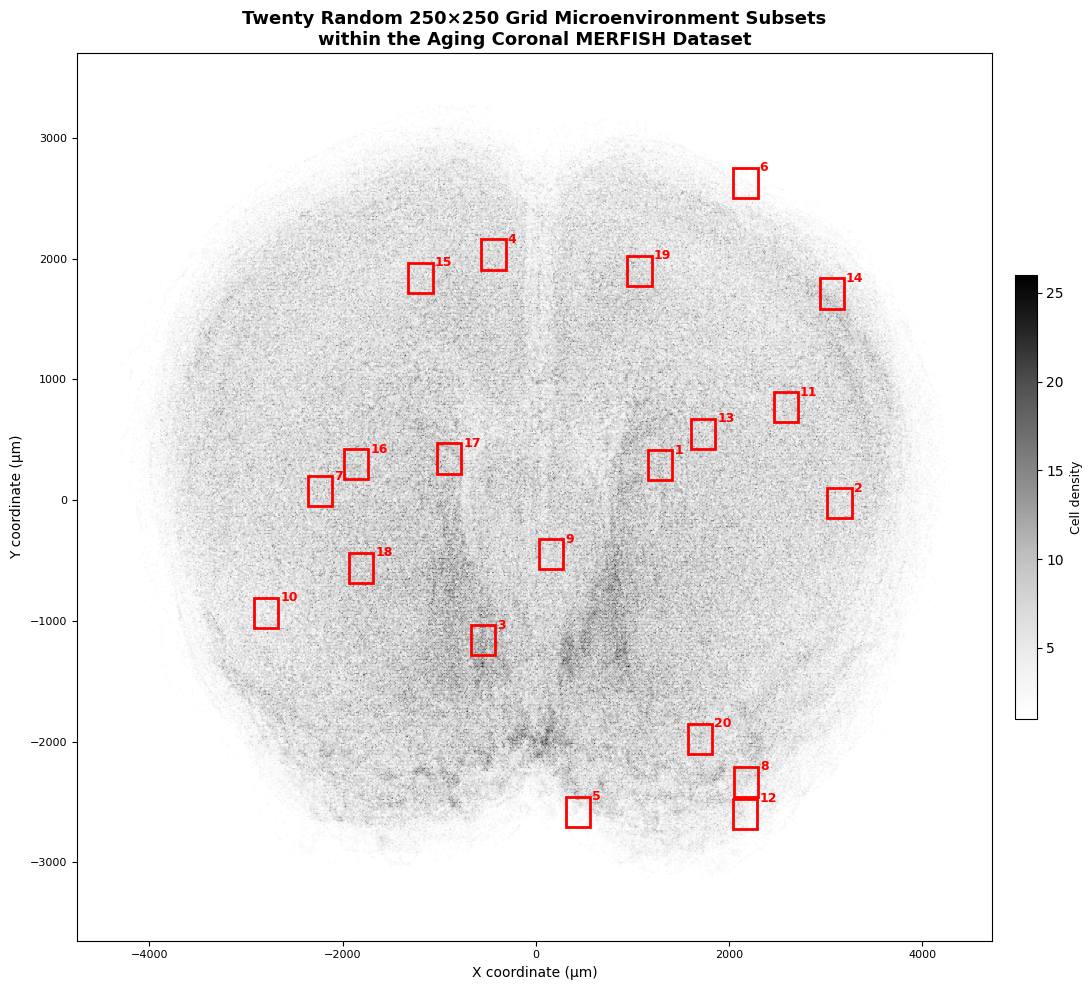

Figure saved as Figure_20_random_grid_overview.png


In [30]:
# ────────────────────────────────────────────
# CHANGED: Plot all 20 grid boxes on the original dataset
# ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))

hb = ax.hexbin(
    spatial["x"],
    spatial["y"],
    gridsize=500,
    cmap="Greys",
    mincnt=1,
    linewidths=0.0
)

cb = fig.colorbar(hb, ax=ax, shrink=0.5, pad=0.02)
cb.set_label("Cell density", fontsize=9)

# CHANGED: draw all 20 grid rectangles
for g in all_grids:

    rect = patches.Rectangle(
        (g["x0"], g["y0"]),
        grid_size,
        grid_size,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
        zorder=5
    )

    ax.add_patch(rect)

    # CHANGED: label each grid with its number
    ax.text(
    g["x0"] + grid_size + 20,   # move text to the right of box
    g["y0"] + grid_size ,    # vertically centered
    str(g["grid_id"]),
    color="red",
    fontsize=9,
    fontweight="bold",
    ha="left",
    va="center",
    zorder=6
)

ax.set_title(
    "Twenty Random 250×250 Grid Microenvironment Subsets\nwithin the Aging Coronal MERFISH Dataset",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("X coordinate (μm)", fontsize=10)
ax.set_ylabel("Y coordinate (μm)", fontsize=10)
ax.tick_params(labelsize=8)

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "Figure_20_random_grid_overview.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved as Figure_20_random_grid_overview.png")

### Loop over the output files do the normalization total count and log1p transform

In [31]:
input_dir = "/home/akram/share/Multiple_Grids"

In [32]:
output_dir = "/home/akram/share/Multiple_Grids/COMMOT"
os.makedirs(output_dir, exist_ok=True)

In [33]:
grid_files = sorted([
    f for f in os.listdir(input_dir)
    if f.startswith("subset_Grid_") and f.endswith(".h5ad")
])

print(f"Found {len(grid_files)} grid files")

Found 20 grid files


In [34]:
df_cellchat = ct.pp.ligand_receptor_database(
    species='mouse',
    database='CellChat'
)

print("Full CellChat database shape:", df_cellchat.shape)

Full CellChat database shape: (1209, 4)


In [35]:
benchmark_results = []

In [38]:
for i, file_name in enumerate(grid_files):

    print("\n" + "="*70)
    print(f"Processing Grid {i+1}/{len(grid_files)}")
    print(f"File: {file_name}")
    print("="*70)

    file_path = os.path.join(input_dir, file_name)

    # ────────────────────────────────────────
    # Load grid
    # ────────────────────────────────────────

    Grid_adata = sc.read_h5ad(file_path)

    print(Grid_adata)

    # ────────────────────────────────────────
    # Preprocessing
    # ────────────────────────────────────────

    Grid_adata.var_names_make_unique()

    Grid_adata.raw = Grid_adata.copy()

    sc.pp.normalize_total(Grid_adata, inplace=True)

    sc.pp.log1p(Grid_adata)

    # ────────────────────────────────────────
    # Filter LR database for this grid
    # ────────────────────────────────────────

    df_cellchat_filtered = ct.pp.filter_lr_database(
        df_cellchat,
        Grid_adata,
        min_cell_pct=0.05
    )

    print("Filtered LR database shape:",
          df_cellchat_filtered.shape)

    print(df_cellchat_filtered.head())

    # ────────────────────────────────────────
    # Benchmark runtime + memory
    # ────────────────────────────────────────

    process = psutil.Process(os.getpid())

    start = time.time()

    # ────────────────────────────────────────
    # Run COMMOT
    # ────────────────────────────────────────

    ct.tl.spatial_communication(
        Grid_adata,
        database_name='cellchat',
        df_ligrec=df_cellchat_filtered,
        dis_thr=500,
        heteromeric=True,
        pathway_sum=True
    )

    end = time.time()

    # ────────────────────────────────────────
    # Memory usage
    # ────────────────────────────────────────

    mem = process.memory_info().rss

    for child in process.children(recursive=True):
        try:
            mem += child.memory_info().rss
        except:
            pass

    peak_mem = mem / (1024**2)

    runtime = end - start

    print(f"Runtime: {runtime:.2f} sec")
    print(f"Peak Memory: {peak_mem:.2f} MiB")

    # ────────────────────────────────────────
    # Save processed object
    # CHANGED: each processed COMMOT result saved
    # ────────────────────────────────────────

    output_file = os.path.join(
        output_dir,
        file_name.replace(".h5ad", "_COMMOT.h5ad")
    )

    Grid_adata.write_h5ad(output_file)

    print(f"Saved: {output_file}")

    # ────────────────────────────────────────
    # Save benchmark results
    # ────────────────────────────────────────

    benchmark_results.append({
        "grid_file": file_name,
        "n_cells": Grid_adata.n_obs,
        "n_genes": Grid_adata.n_vars,
        "filtered_lr_pairs": df_cellchat_filtered.shape[0],
        "runtime_sec": runtime,
        "peak_memory_MiB": peak_mem
    })

    # ────────────────────────────────────────
    # Cleanup memory
    # CHANGED: important for large loops
    # ────────────────────────────────────────

    del Grid_adata
    del df_cellchat_filtered

    gc.collect()


Processing Grid 1/20
File: subset_Grid_1.h5ad
AnnData object with n_obs × n_vars = 2812 × 300
    obs: 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'transcript_count', 'num_detected_genes', 'barcodeCount', 'mouse_id', 'slide_id', 'cohort', 'age', 'batch', 'celltype', 'region', 'subregion'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
Filtered LR database shape: (5, 4)
       0              1     2                   3
0   Fgf2          Fgfr3   FGF  Secreted Signaling
1  Vegfa           Flt1  VEGF  Secreted Signaling
2   Igf2          Igf1r   IGF  Secreted Signaling
3   Ccl5           Ccr4   CCL  Secreted Signaling
4   Il10  Il10ra_Il10rb  IL10  Secreted Signaling
Runtime: 233.56 sec
Peak Memory: 9254.52 MiB
Saved: /home/akram/share/Multiple_Grids/COMMOT/subset_Grid_1_COMMOT.h5ad

Processing Grid 2/20
File: subset_Grid_10.h5ad
AnnData object with n_obs × n_vars = 1848 × 300
    

In [40]:
print(benchmark_results)

[{'grid_file': 'subset_Grid_1.h5ad', 'n_cells': 2812, 'n_genes': 300, 'filtered_lr_pairs': 5, 'runtime_sec': 233.55816745758057, 'peak_memory_MiB': 9254.5234375}, {'grid_file': 'subset_Grid_10.h5ad', 'n_cells': 1848, 'n_genes': 300, 'filtered_lr_pairs': 5, 'runtime_sec': 187.33719539642334, 'peak_memory_MiB': 9254.52734375}, {'grid_file': 'subset_Grid_11.h5ad', 'n_cells': 2447, 'n_genes': 300, 'filtered_lr_pairs': 5, 'runtime_sec': 189.99053120613098, 'peak_memory_MiB': 9254.52734375}, {'grid_file': 'subset_Grid_12.h5ad', 'n_cells': 1373, 'n_genes': 300, 'filtered_lr_pairs': 5, 'runtime_sec': 37.812743186950684, 'peak_memory_MiB': 9254.52734375}, {'grid_file': 'subset_Grid_13.h5ad', 'n_cells': 2562, 'n_genes': 300, 'filtered_lr_pairs': 5, 'runtime_sec': 148.02713918685913, 'peak_memory_MiB': 9254.55078125}, {'grid_file': 'subset_Grid_14.h5ad', 'n_cells': 2419, 'n_genes': 300, 'filtered_lr_pairs': 6, 'runtime_sec': 2748.4024851322174, 'peak_memory_MiB': 9294.125}, {'grid_file': 'subset_

Found 20 COMMOT files

Processing: subset_Grid_10_COMMOT.h5ad
Found 10 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_10.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_10.csv


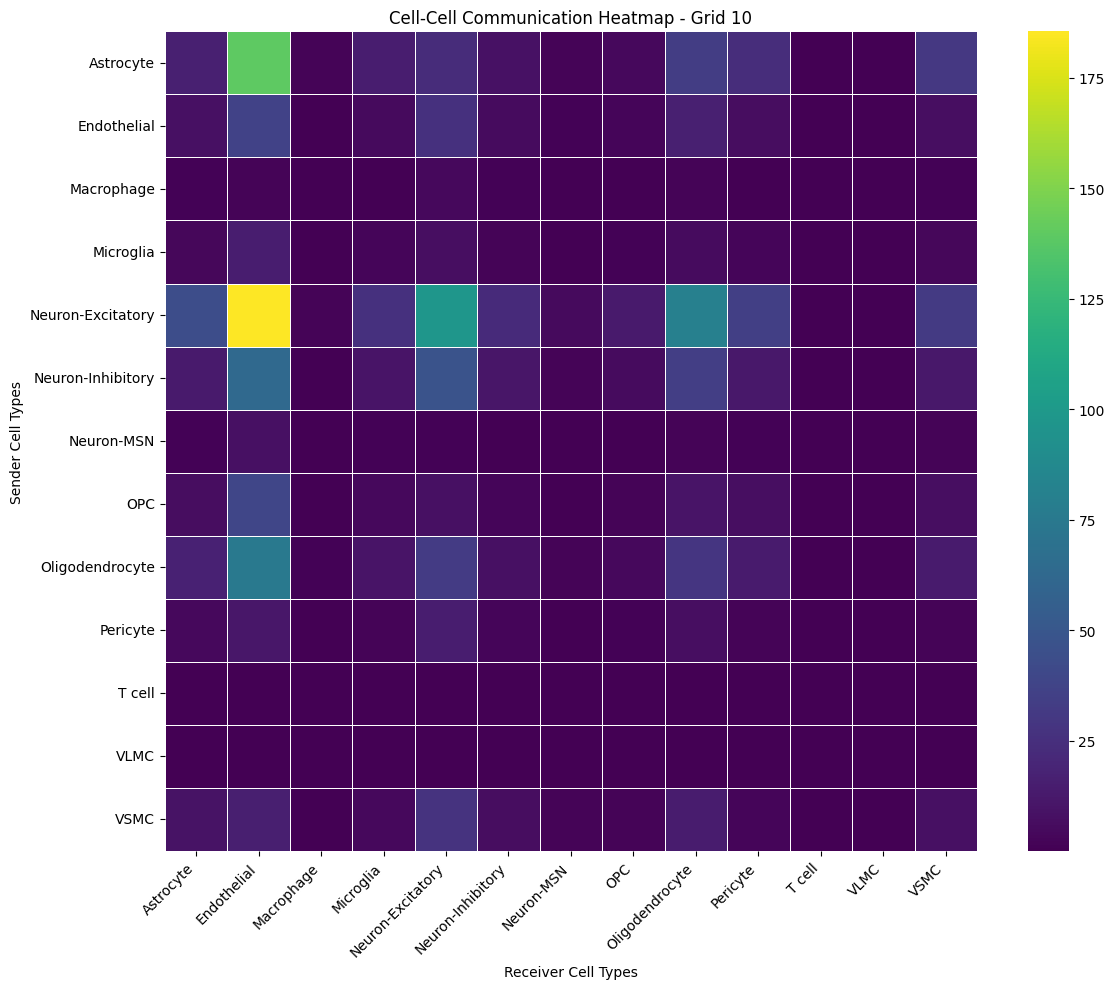

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_10.png

Processing: subset_Grid_11_COMMOT.h5ad
Found 10 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_11.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_11.csv


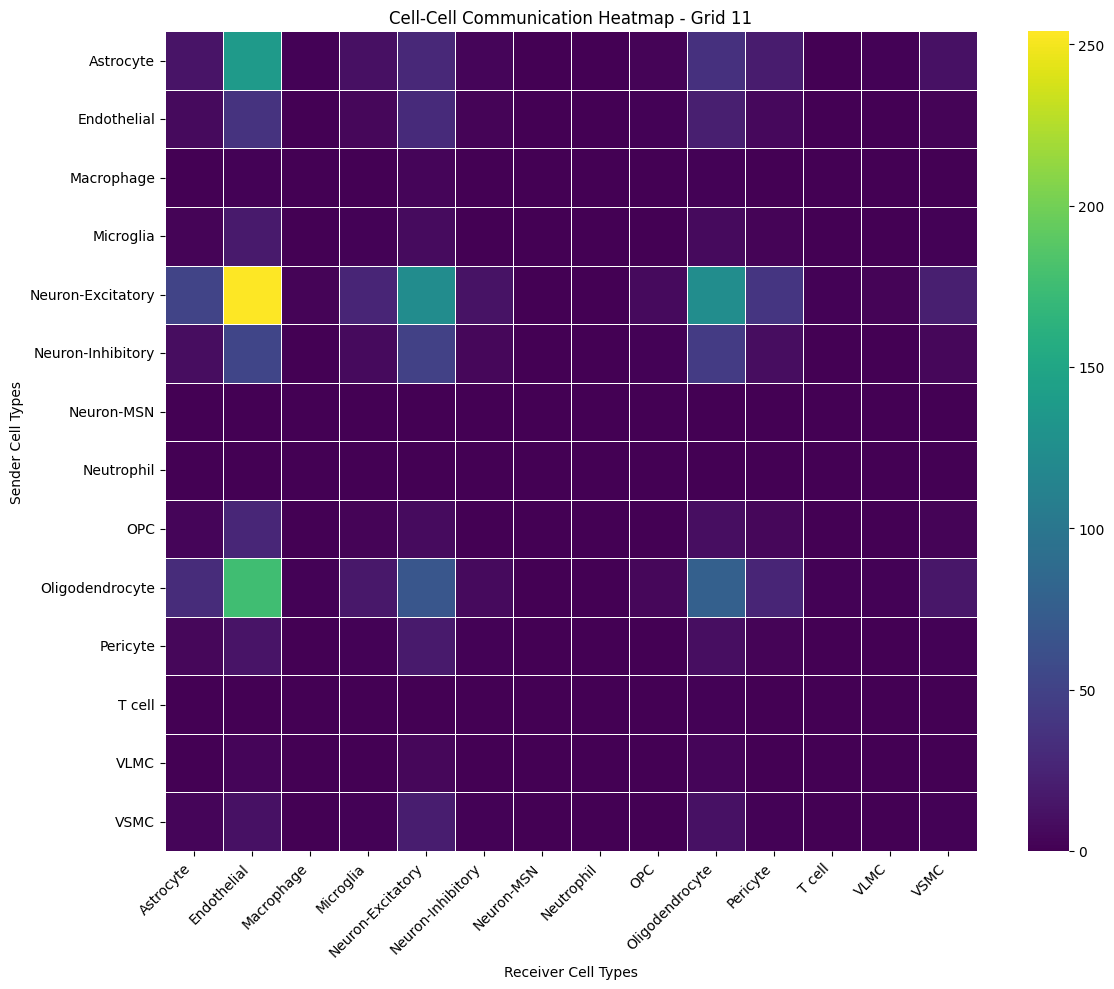

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_11.png

Processing: subset_Grid_12_COMMOT.h5ad
Found 11 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_12.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_12.csv


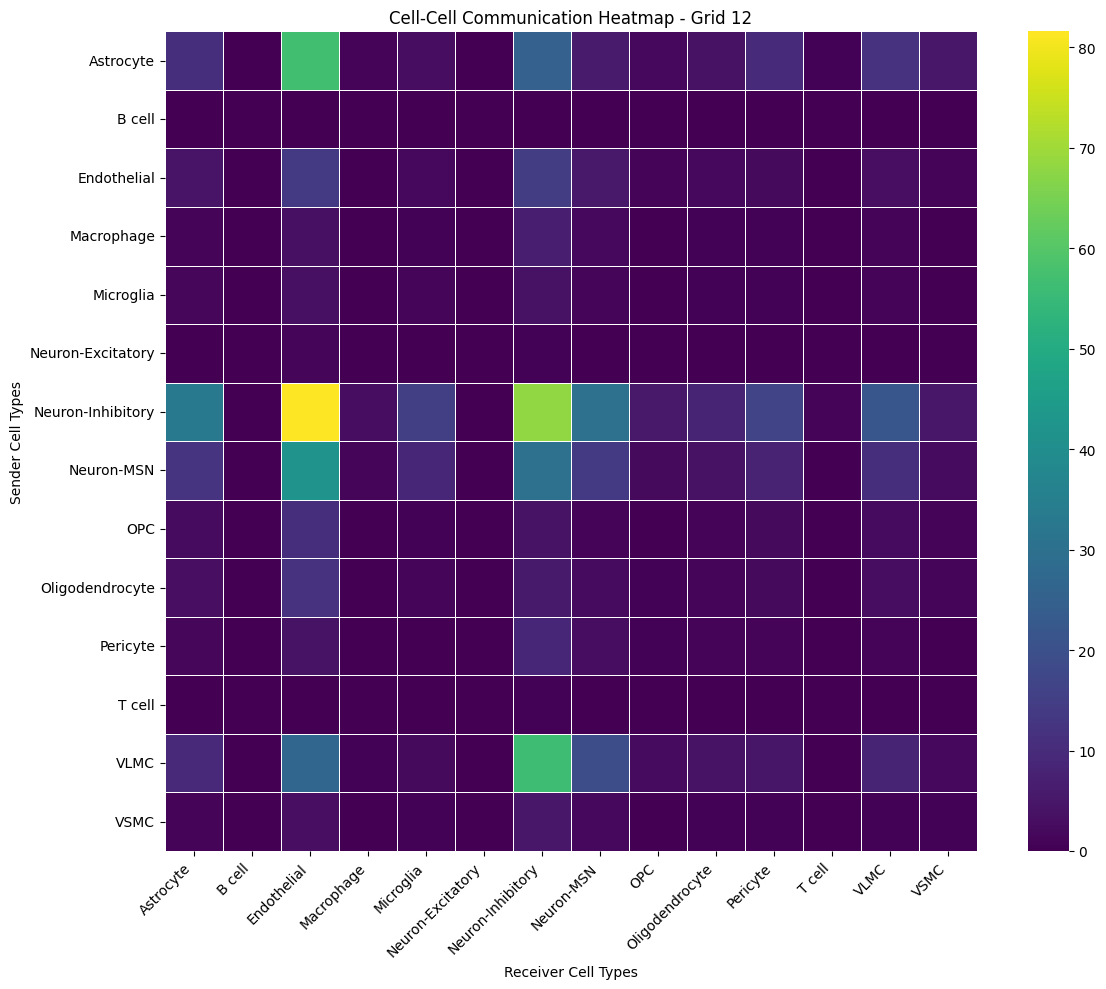

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_12.png

Processing: subset_Grid_13_COMMOT.h5ad
Found 11 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_13.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_13.csv


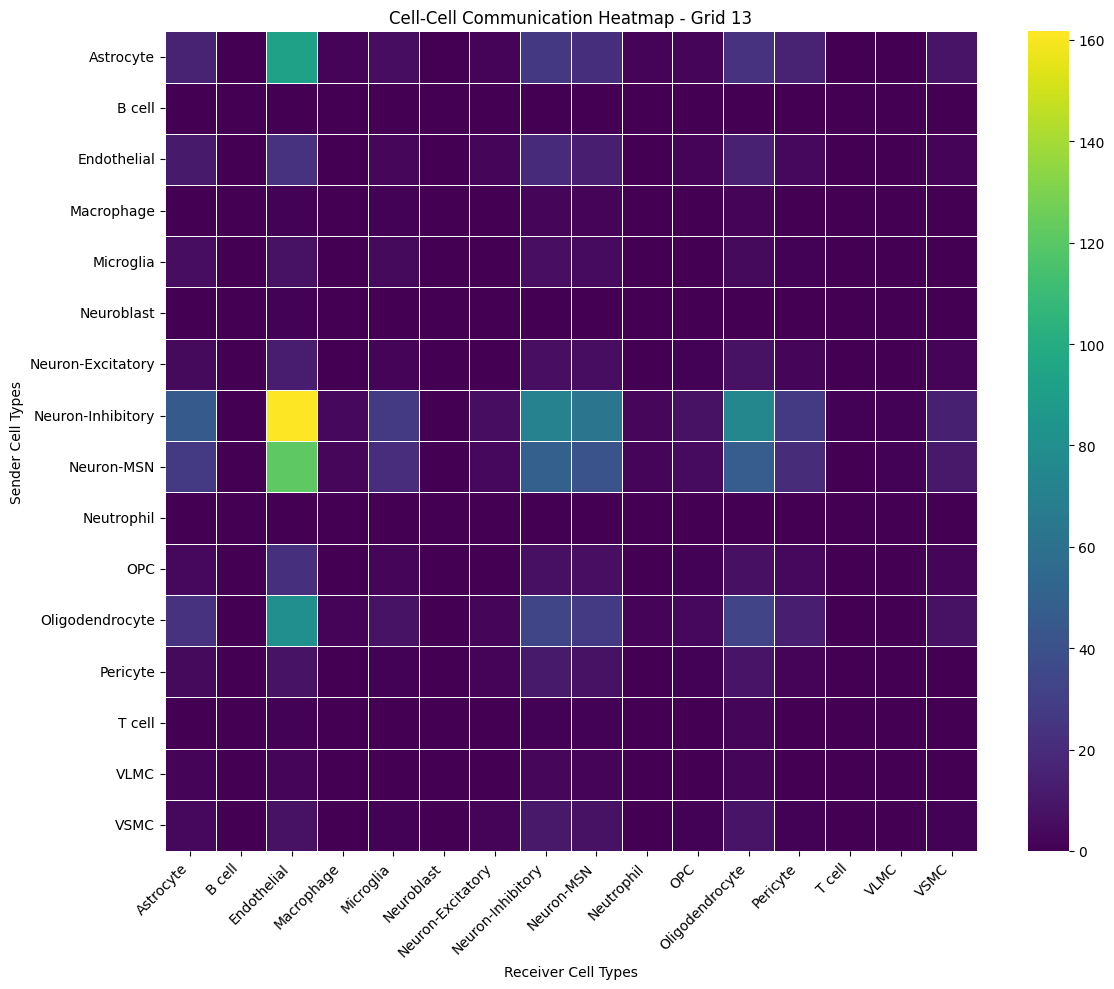

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_13.png

Processing: subset_Grid_14_COMMOT.h5ad
Found 12 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_14.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_14.csv


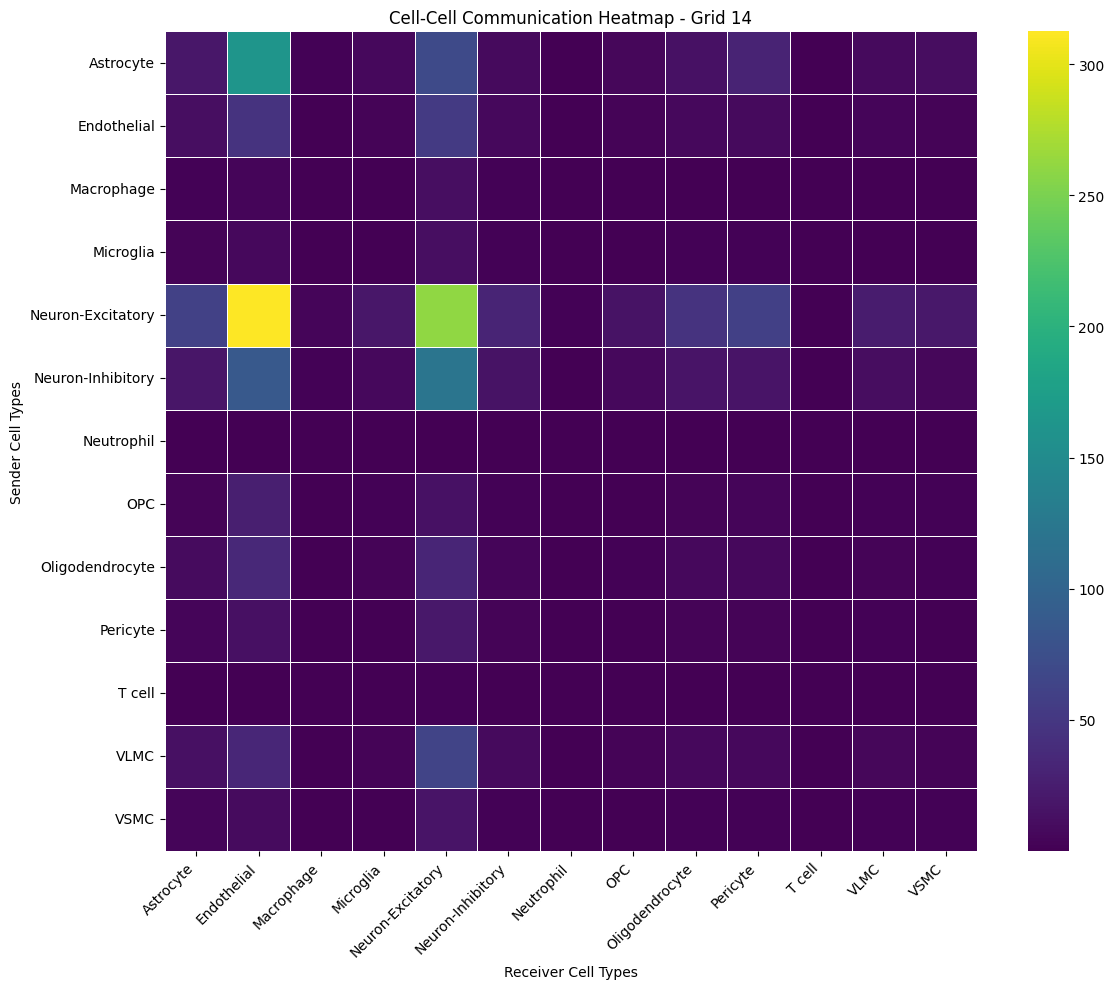

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_14.png

Processing: subset_Grid_15_COMMOT.h5ad
Found 12 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_15.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_15.csv


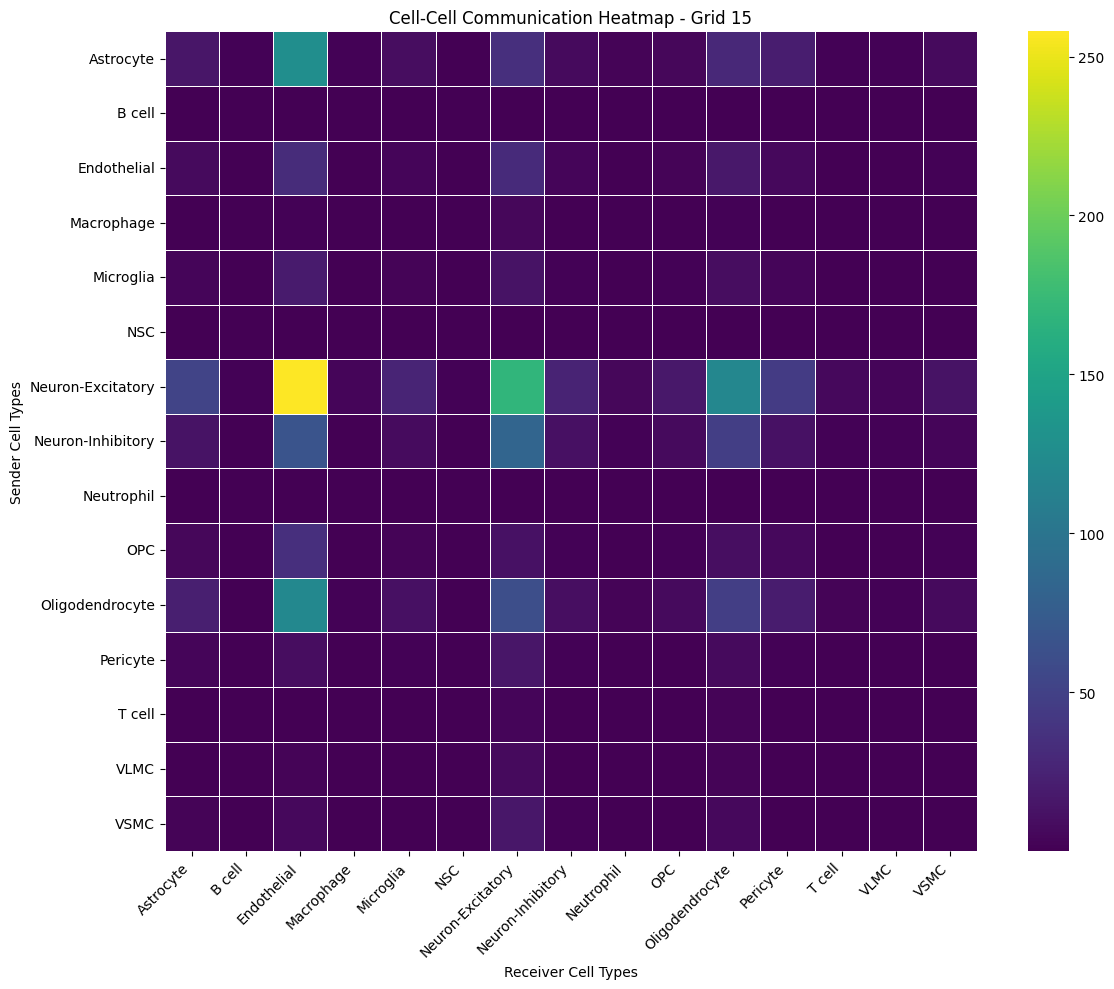

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_15.png

Processing: subset_Grid_16_COMMOT.h5ad
Found 11 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_16.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_16.csv


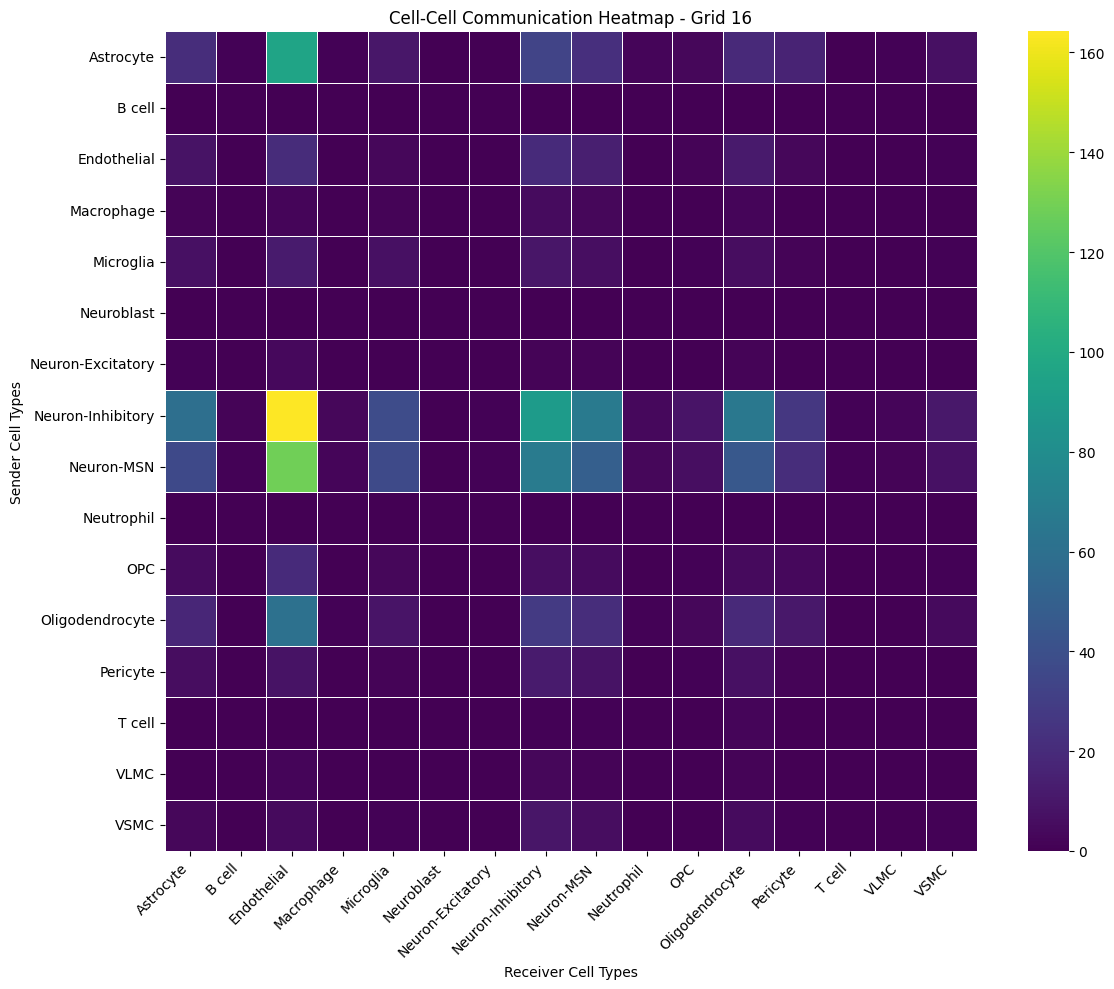

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_16.png

Processing: subset_Grid_17_COMMOT.h5ad
Found 11 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_17.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_17.csv


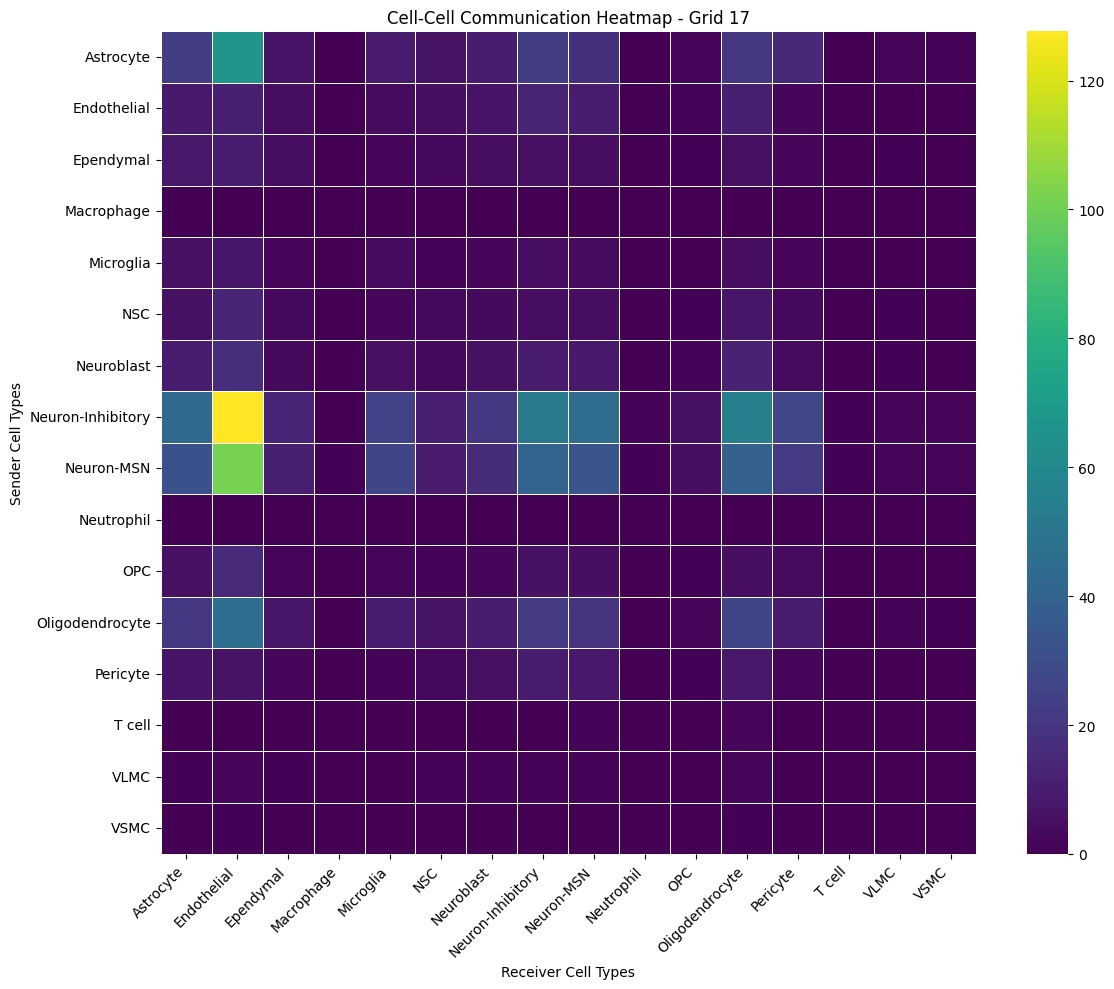

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_17.png

Processing: subset_Grid_18_COMMOT.h5ad
Found 12 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_18.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_18.csv


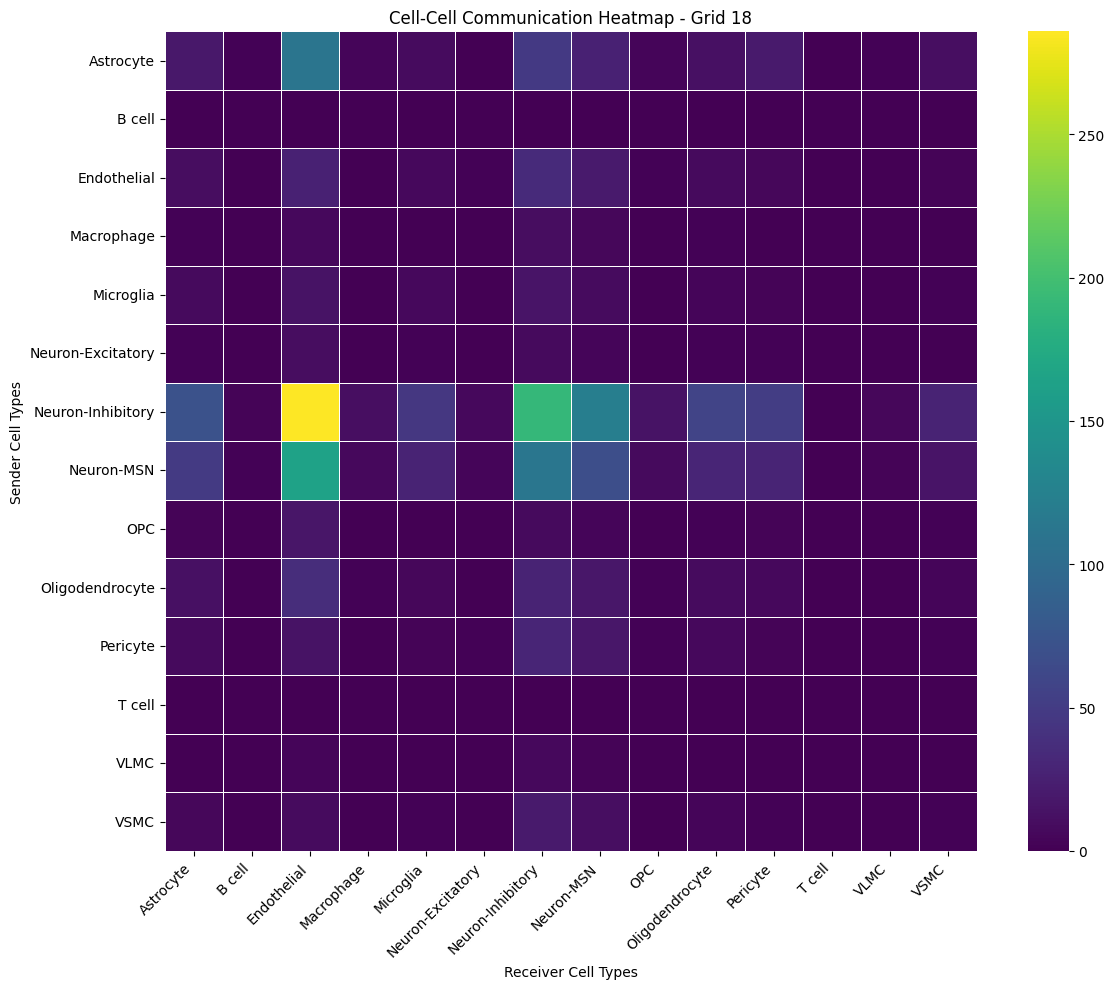

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_18.png

Processing: subset_Grid_19_COMMOT.h5ad
Found 10 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_19.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_19.csv


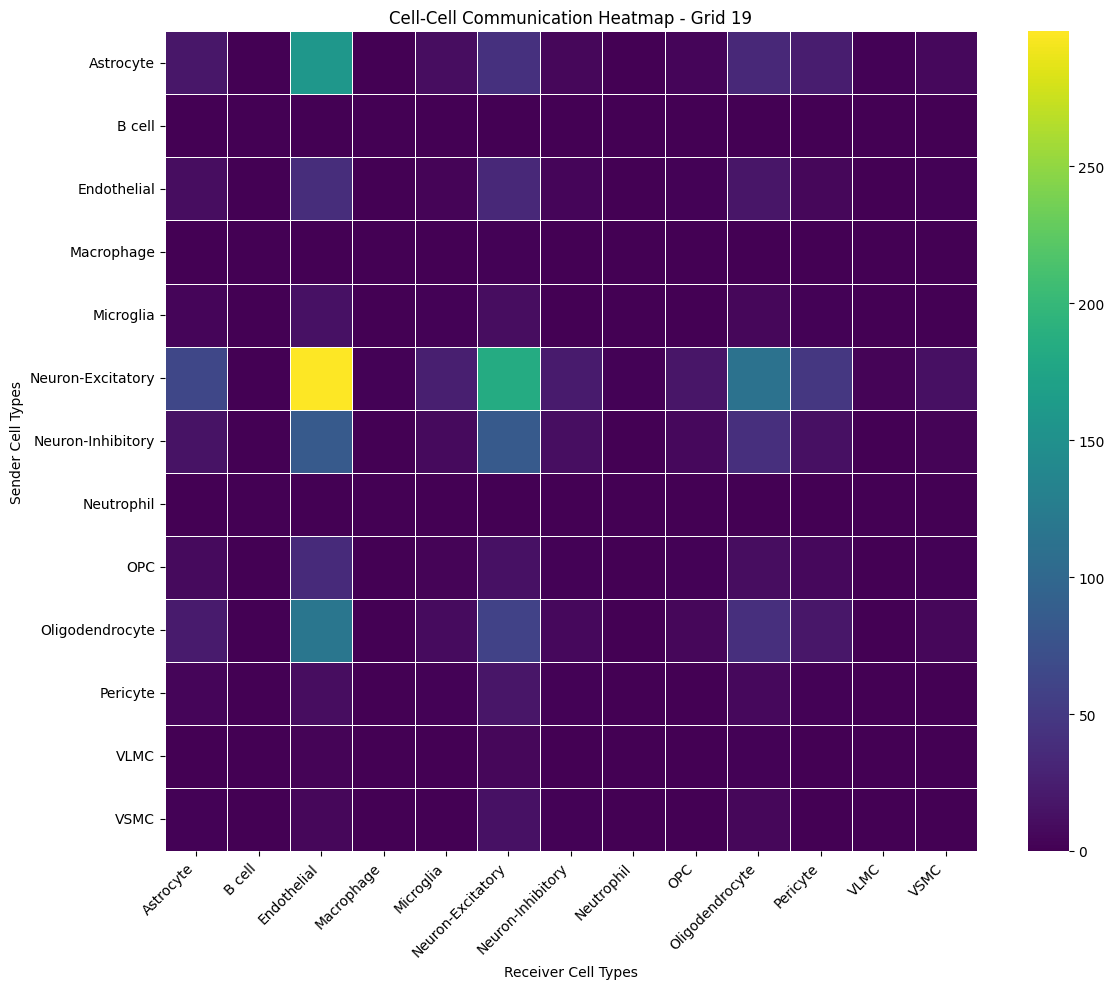

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_19.png

Processing: subset_Grid_1_COMMOT.h5ad
Found 11 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_1.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_1.csv


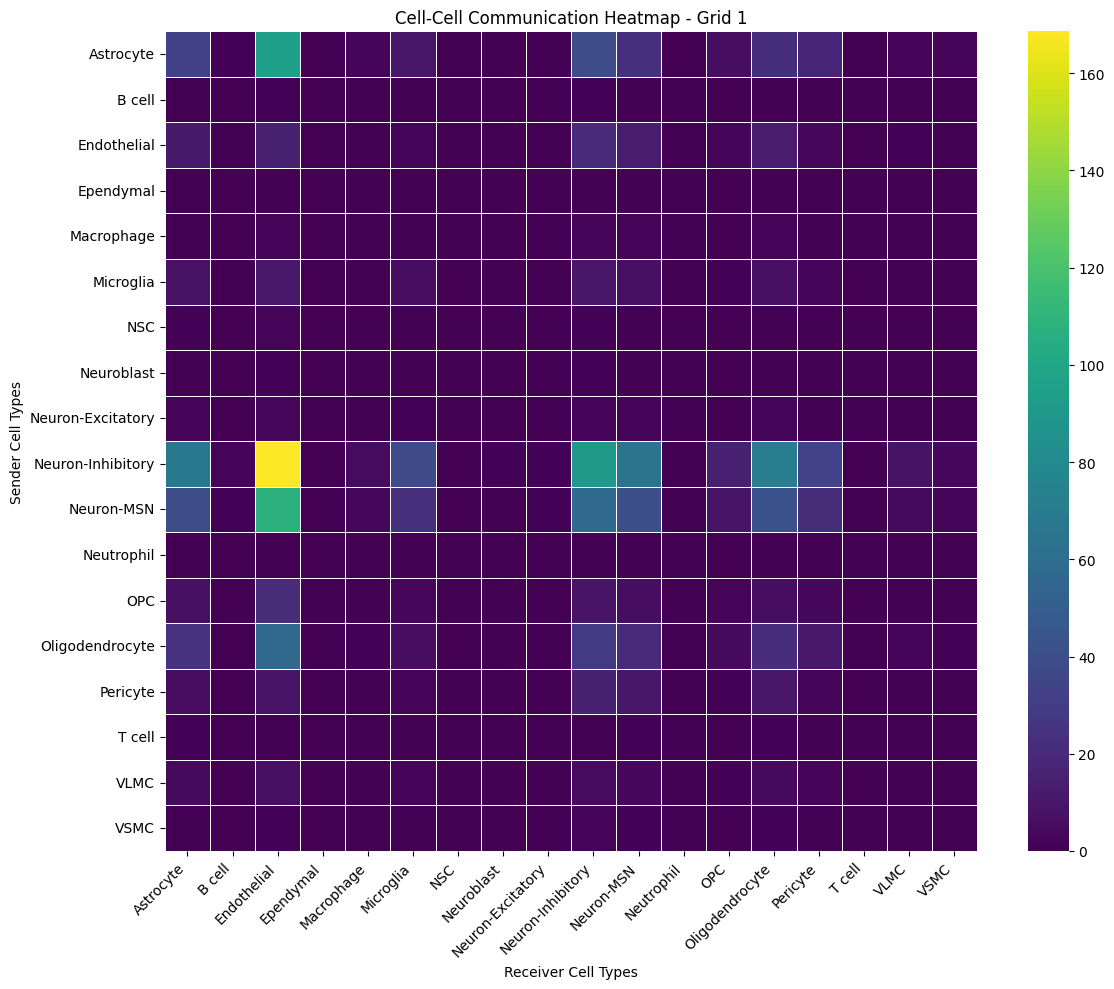

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_1.png

Processing: subset_Grid_20_COMMOT.h5ad
Found 12 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_20.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_20.csv


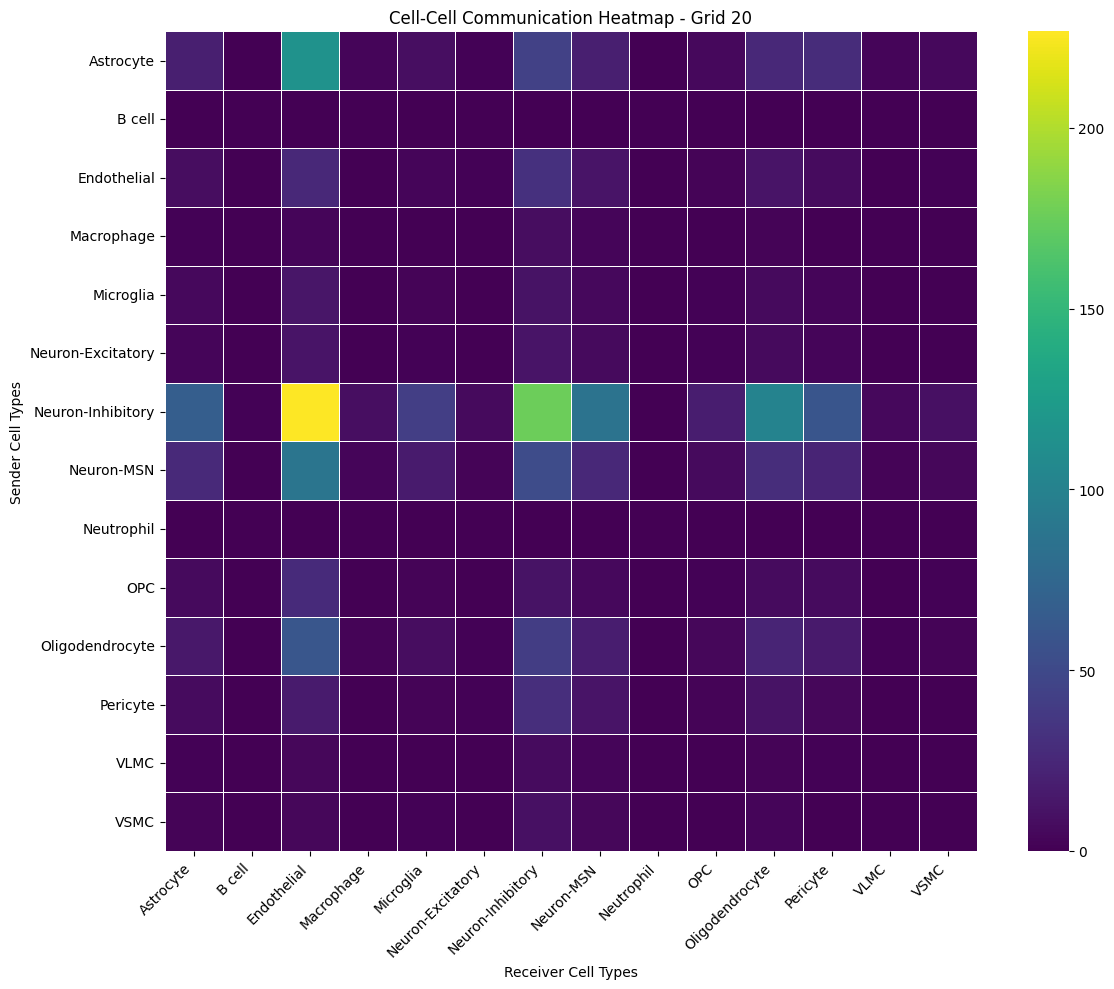

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_20.png

Processing: subset_Grid_2_COMMOT.h5ad
Found 10 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_2.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_2.csv


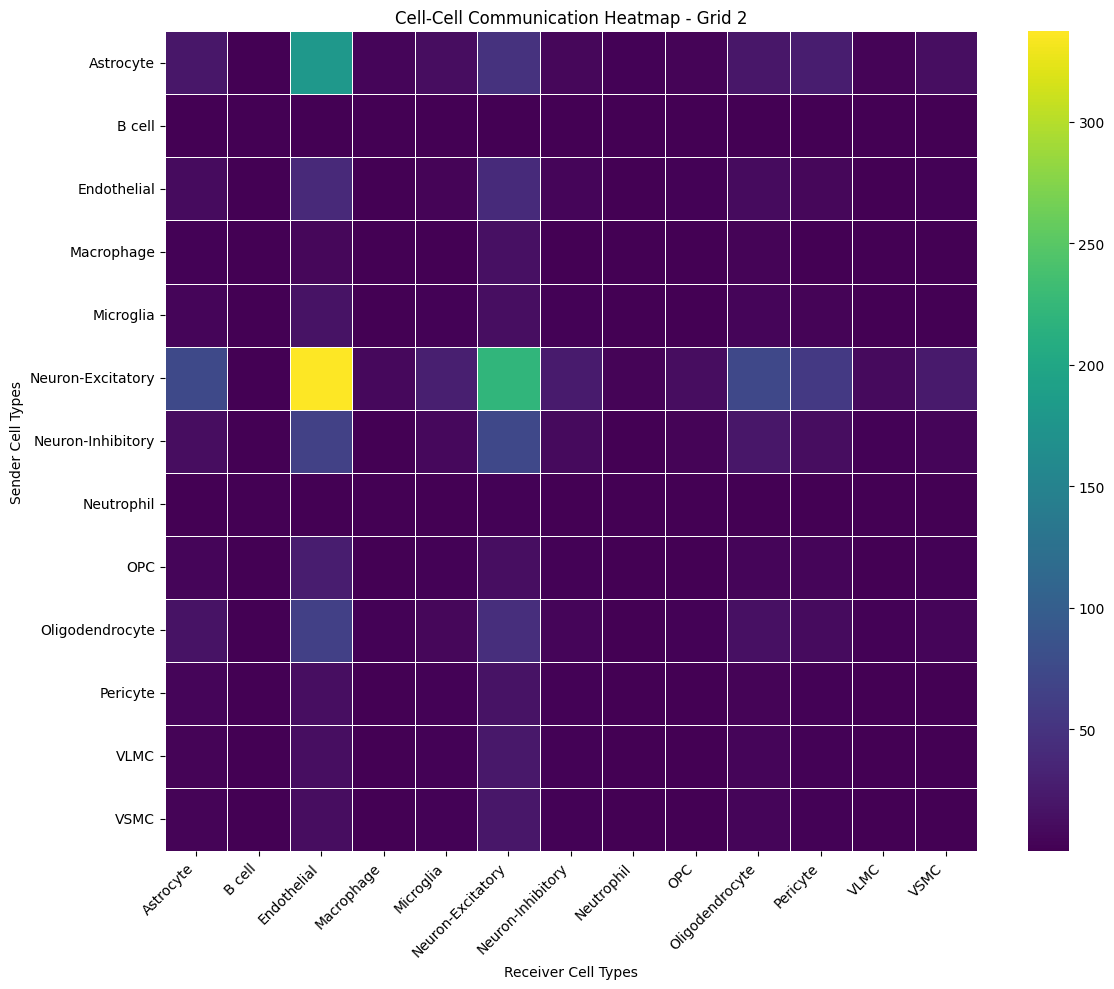

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_2.png

Processing: subset_Grid_3_COMMOT.h5ad
Found 12 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_3.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_3.csv


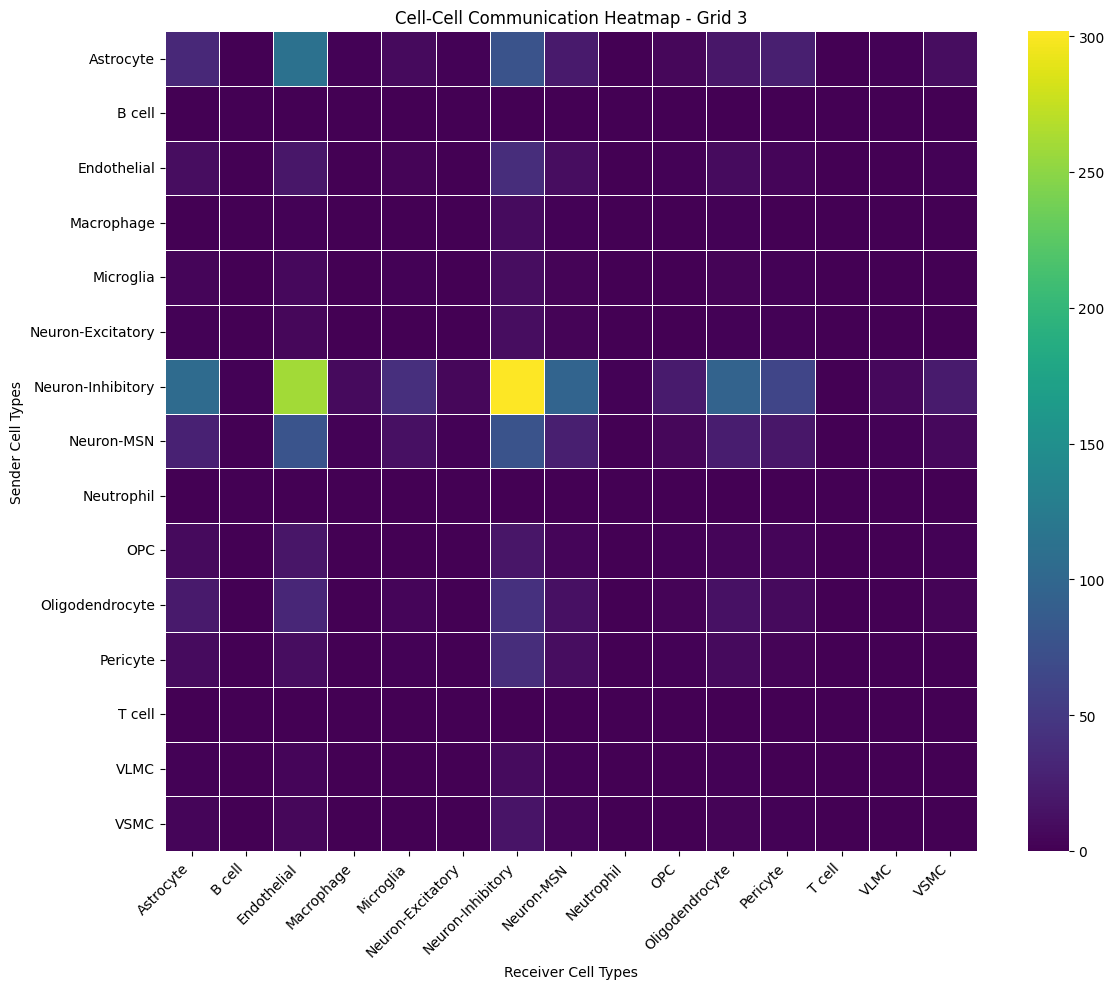

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_3.png

Processing: subset_Grid_4_COMMOT.h5ad
Found 10 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_4.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_4.csv


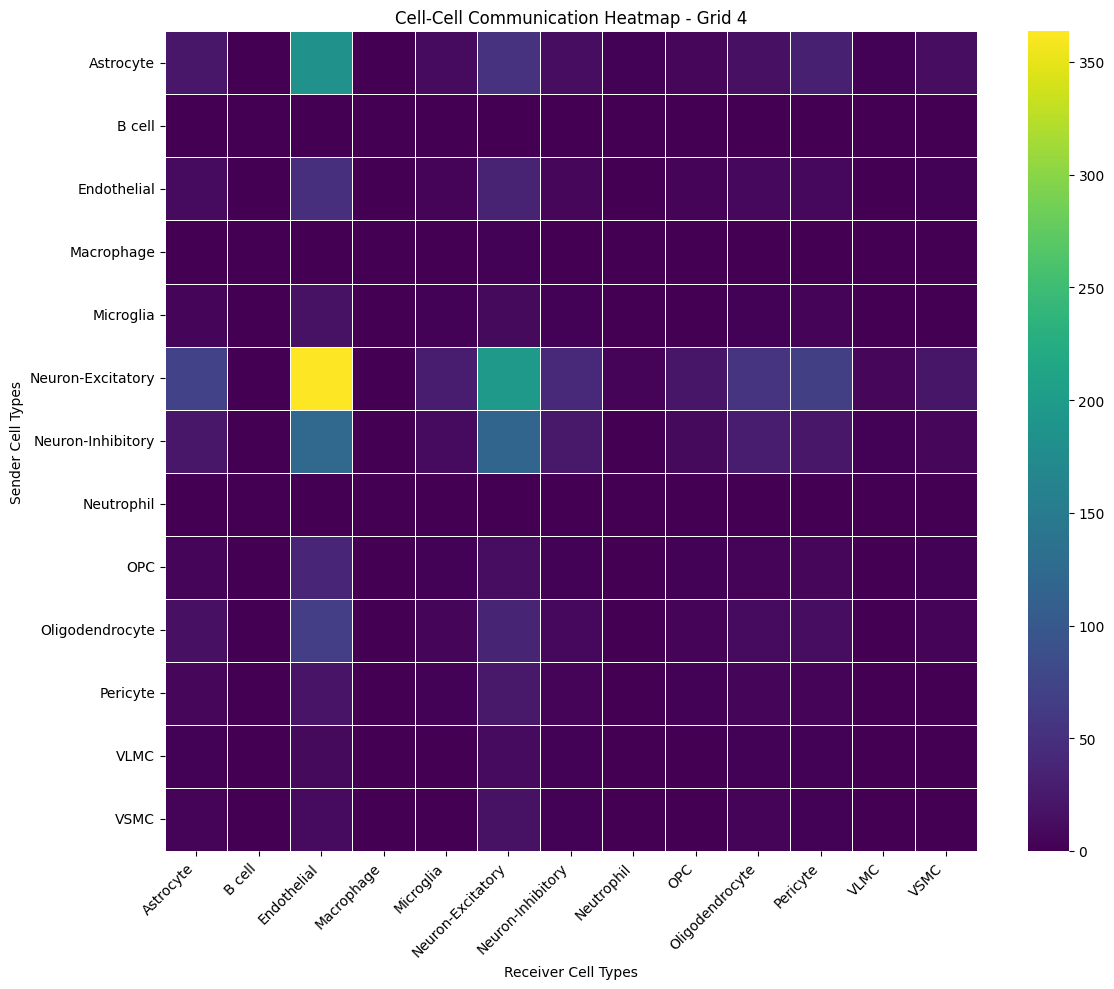

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_4.png

Processing: subset_Grid_5_COMMOT.h5ad
Found 12 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_5.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_5.csv


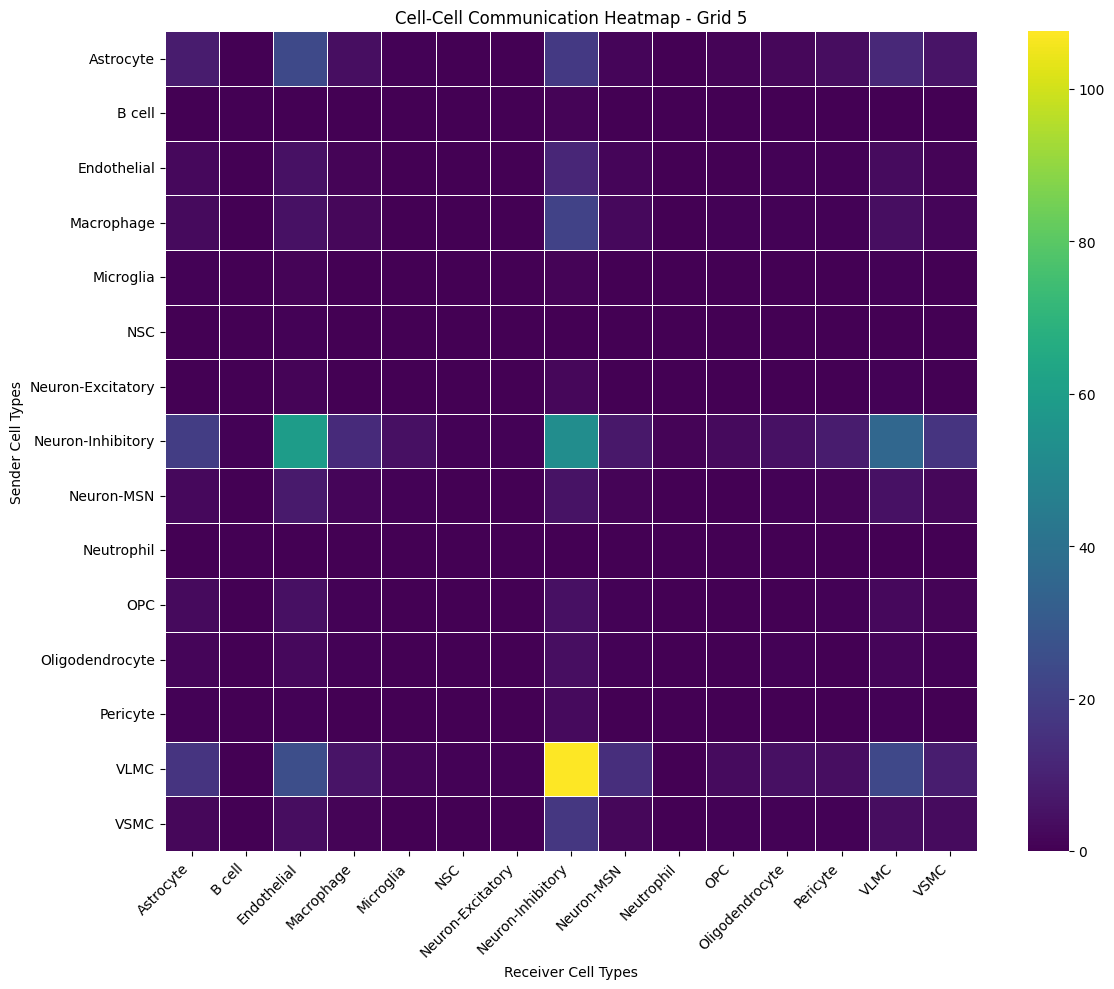

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_5.png

Processing: subset_Grid_6_COMMOT.h5ad
Found 10 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_6.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_6.csv


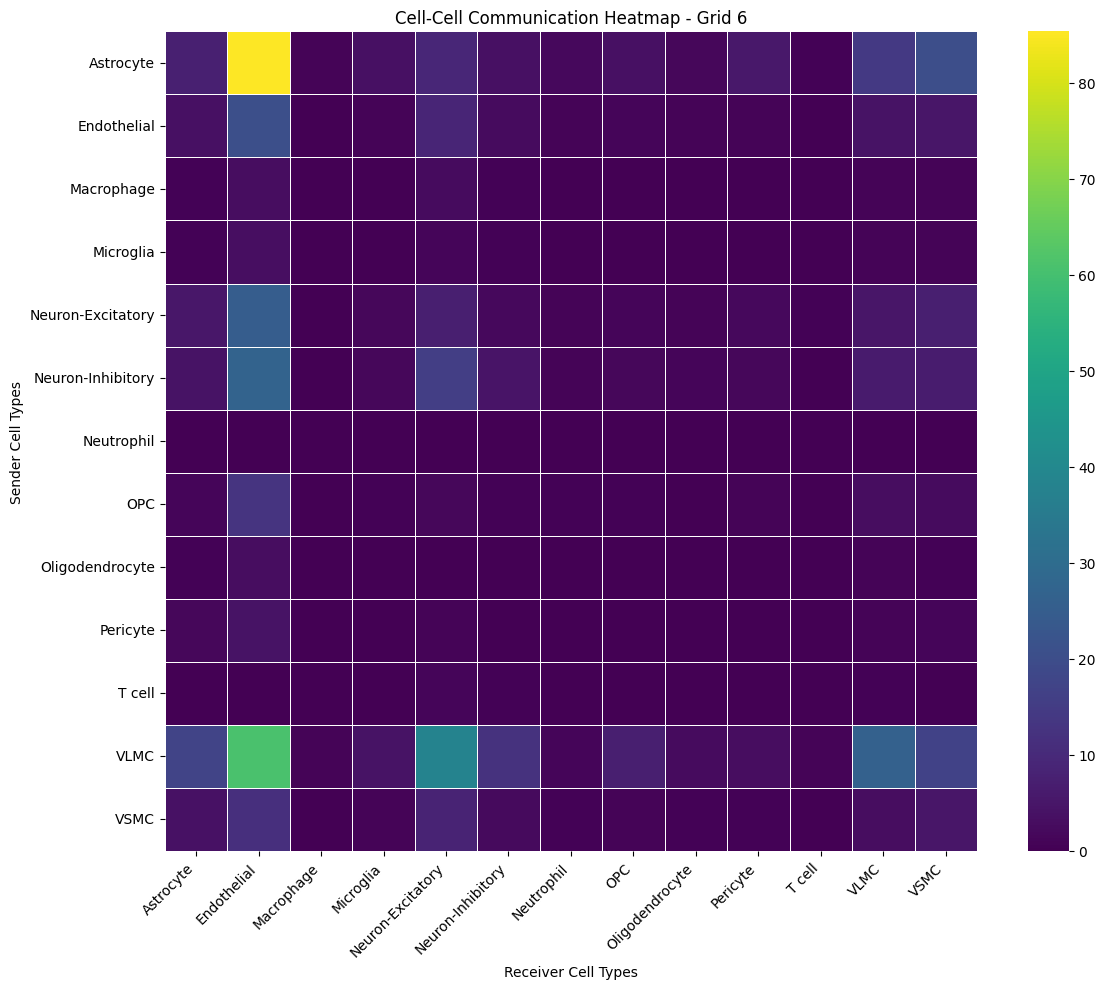

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_6.png

Processing: subset_Grid_7_COMMOT.h5ad
Found 12 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_7.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_7.csv


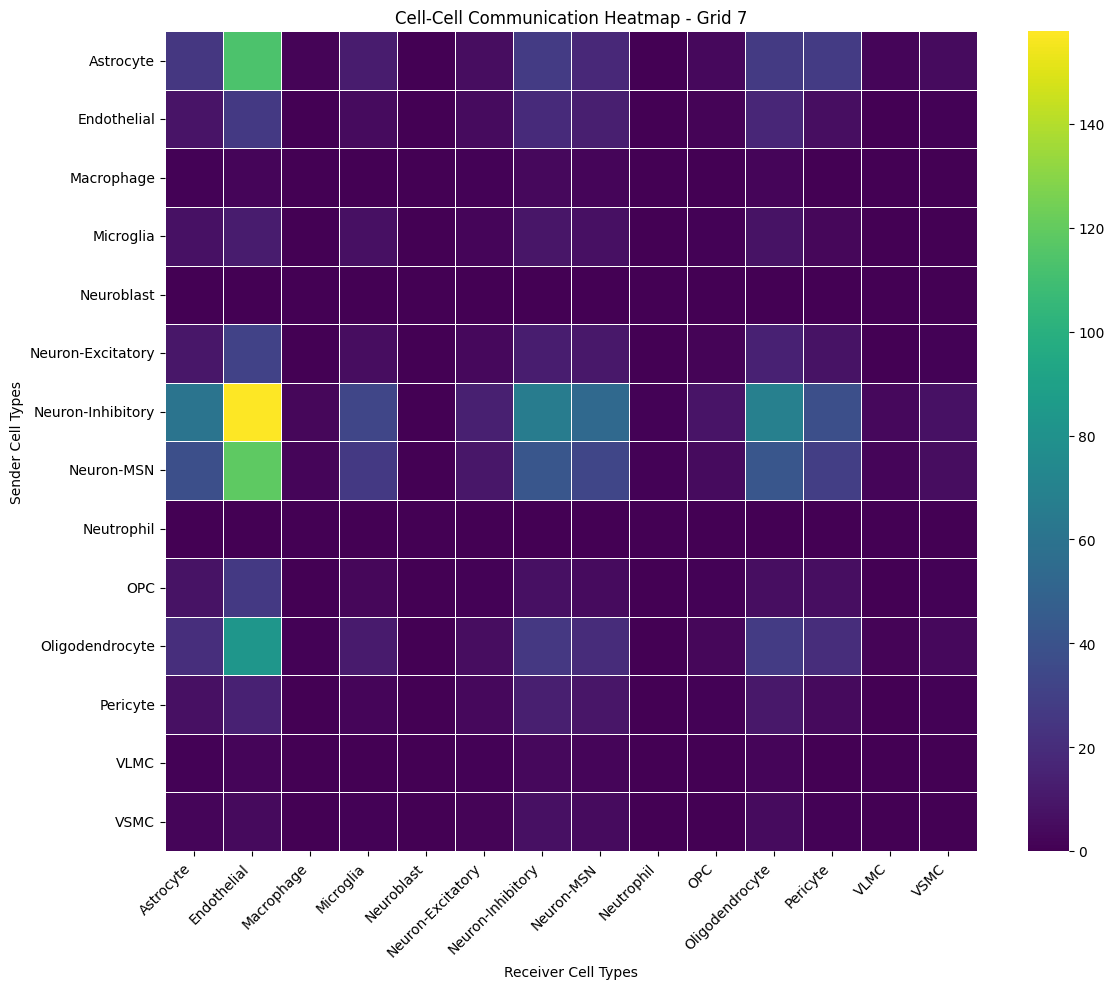

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_7.png

Processing: subset_Grid_8_COMMOT.h5ad
Found 12 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_8.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_8.csv


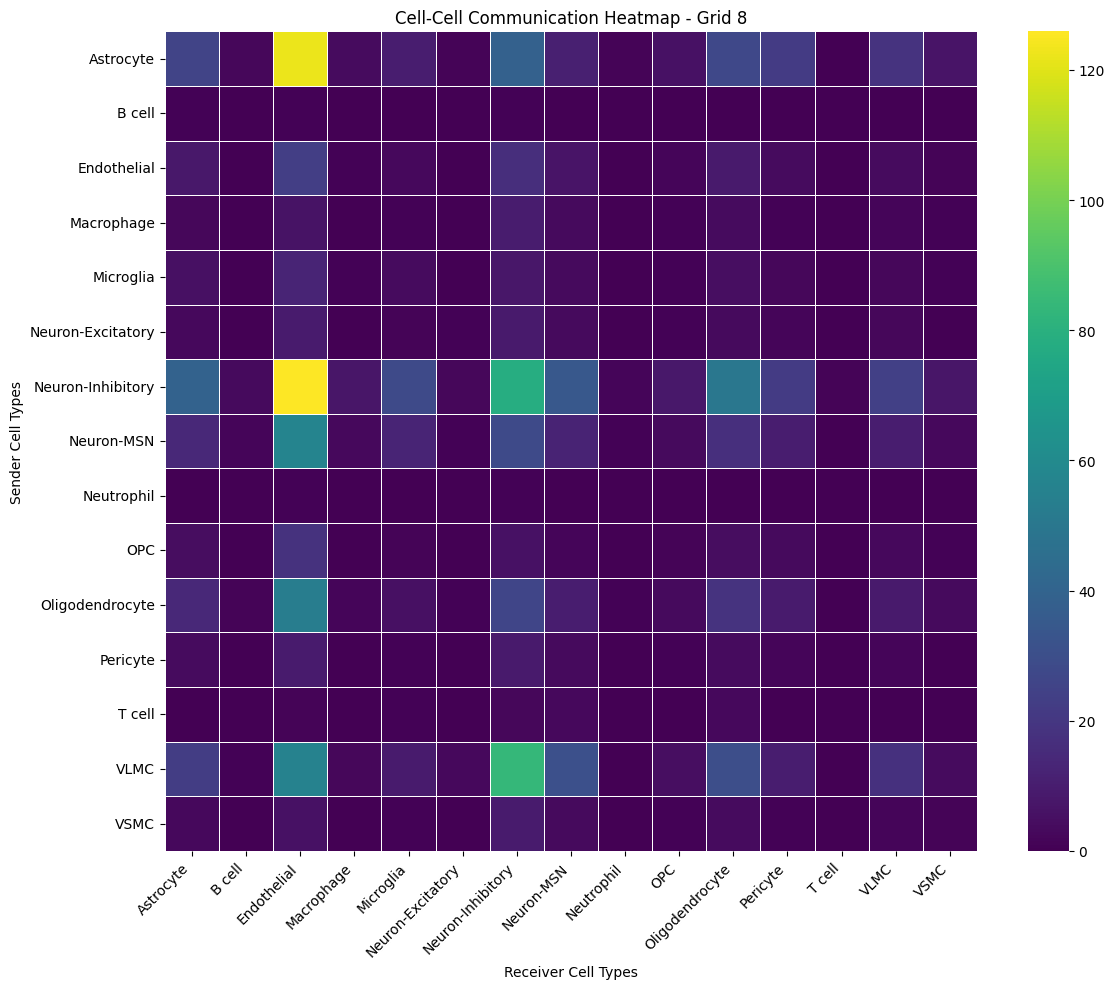

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_8.png

Processing: subset_Grid_9_COMMOT.h5ad
Found 12 COMMOT matrices
Saved LR summary: /home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_Grid_9.csv
Saved matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_Grid_9.csv


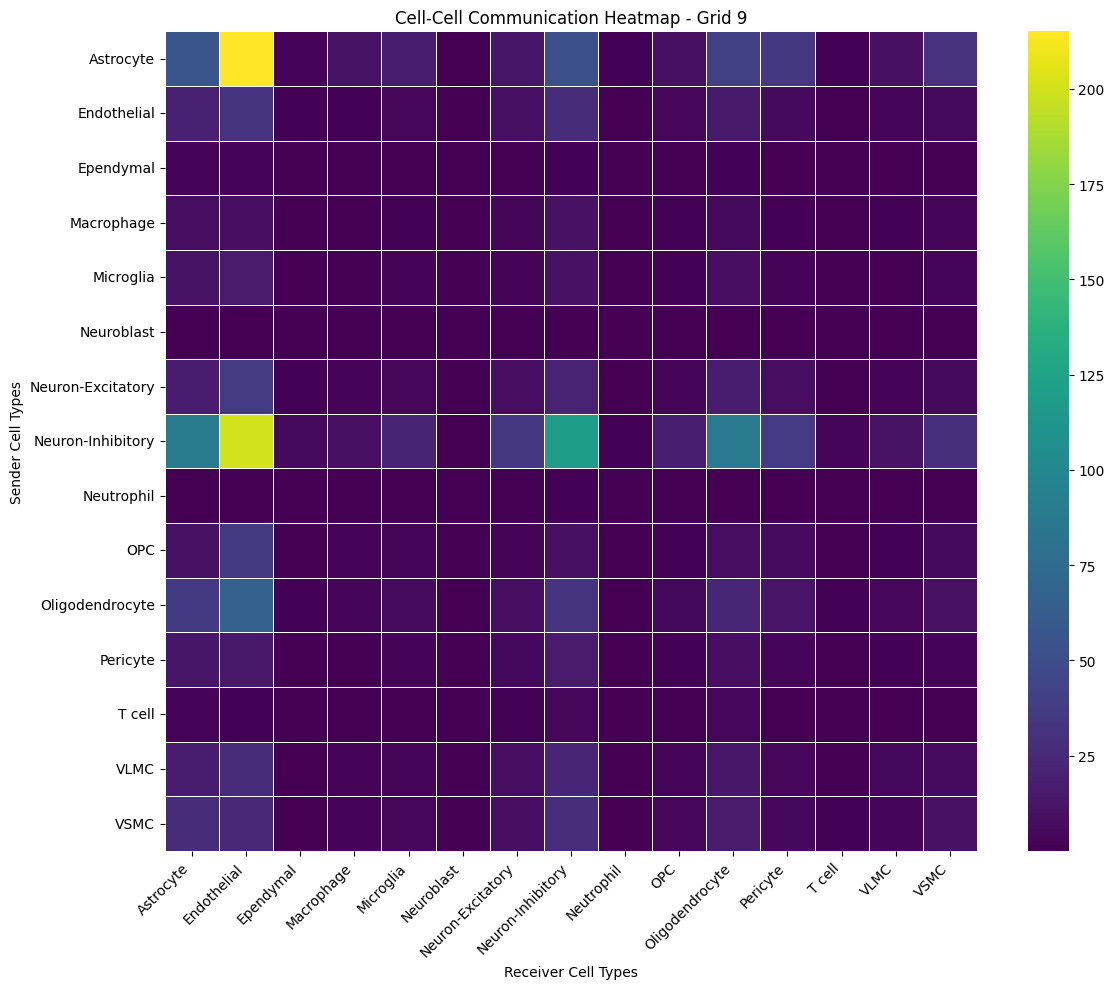

Saved heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_Grid_9.png

Saved combined LR summary:
/home/akram/share/Multiple_Grids/COMMOT/Grid/all_lr_interactions_ALL_GRIDS_full.csv


,sender_cell_type,LR_pair,grid_id,receiver_cell_type,interaction_strength
0,Astrocyte,CCL,10,Astrocyte,0.296286
1,Endothelial,CCL,10,Astrocyte,0.477989
2,Macrophage,CCL,10,Astrocyte,0.090094
3,Microglia,CCL,10,Astrocyte,0.198599
4,Neuron-Excitatory,CCL,10,Astrocyte,4.964604


Saved mean matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_MEAN_ALL_GRIDS.csv
Saved std matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_STD_ALL_GRIDS.csv
Saved CV matrix: /home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_CV_ALL_GRIDS.csv


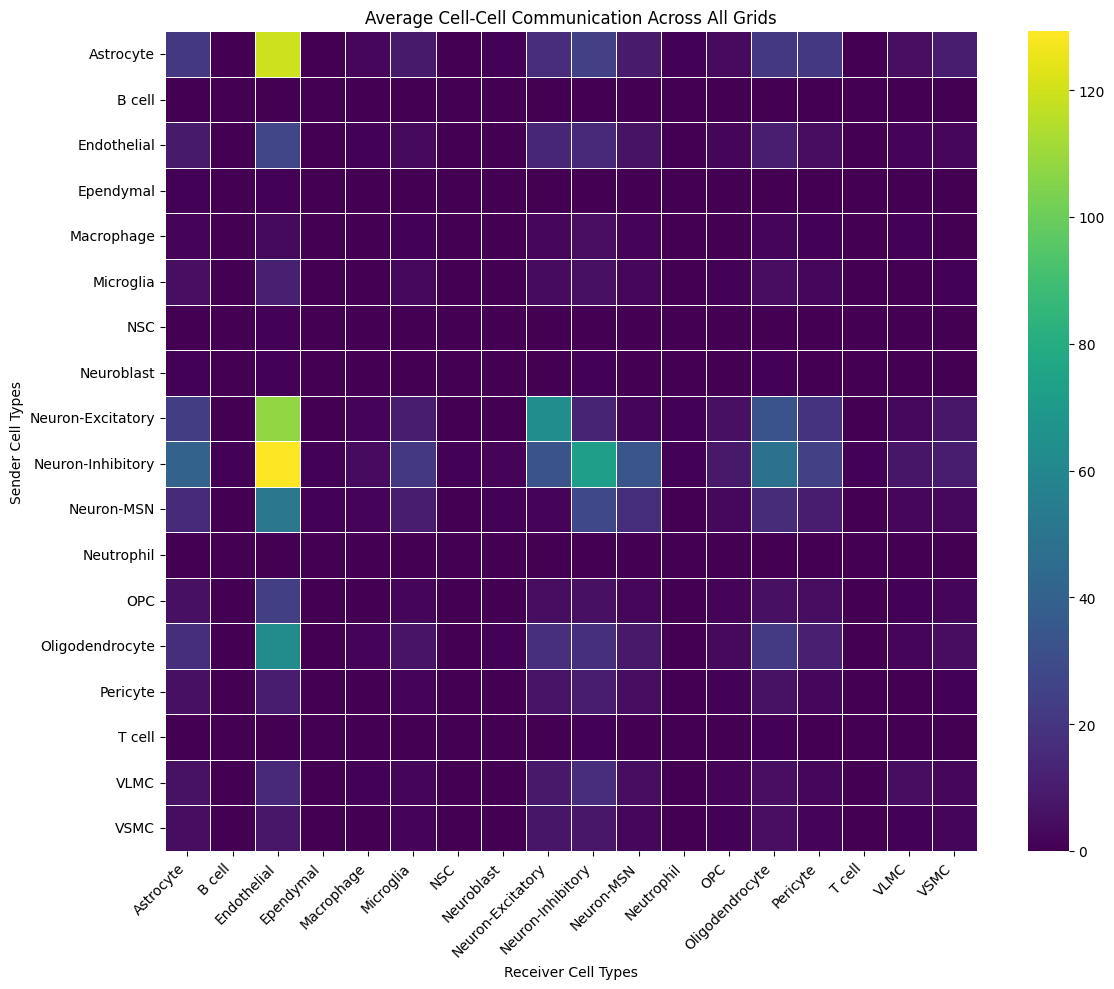

Saved average heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_MEAN_ALL_GRIDS.png


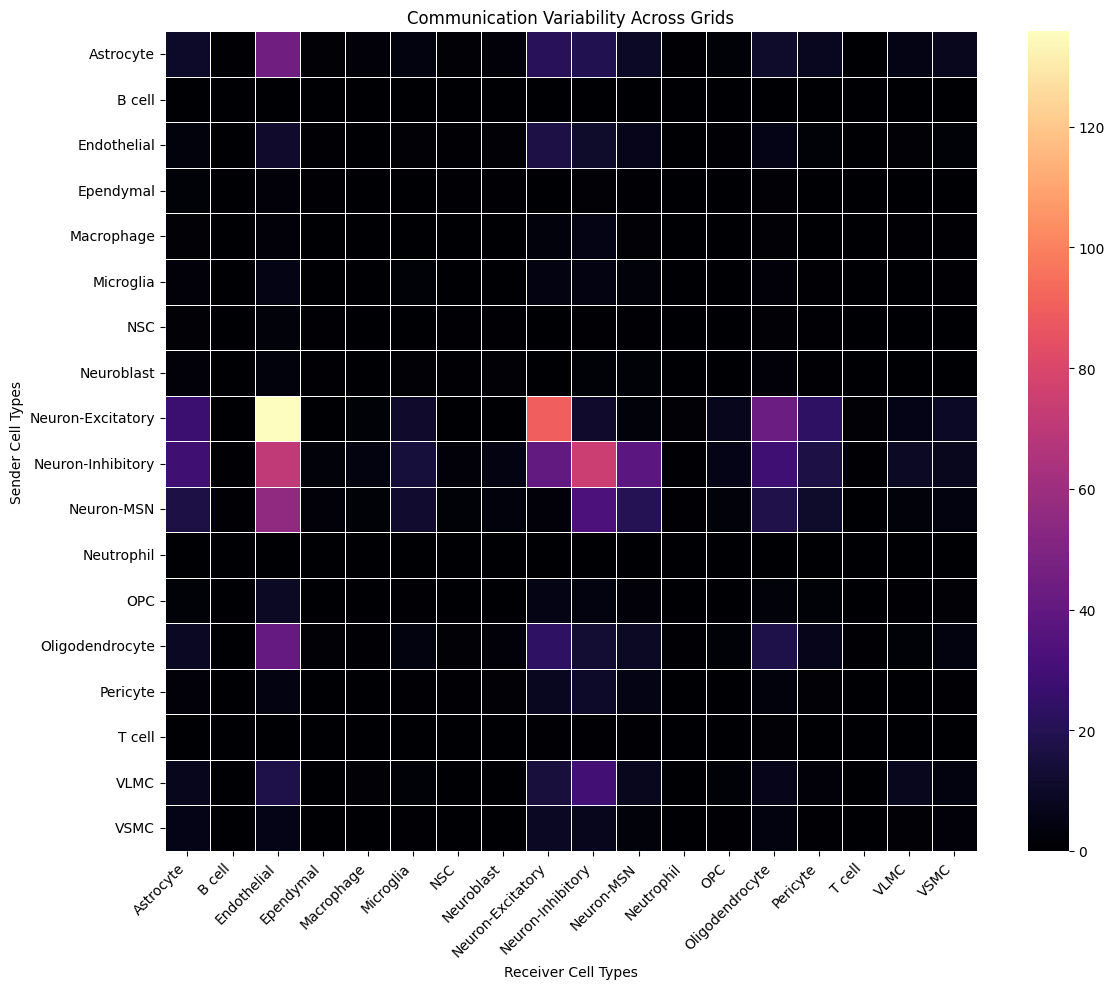

Saved variability heatmap: /home/akram/share/Multiple_Grids/COMMOT/heatmaps/COMMOT_heatmap_STD_ALL_GRIDS.png


In [ ]:
commot_dir = "/home/akram/share/Multiple_Grids/COMMOT"

summary_dir = "/home/akram/share/Multiple_Grids/COMMOT/Grid"
matrix_dir = "/home/akram/share/Multiple_Grids/COMMOT/comparsion_output"
heatmap_dir = "/home/akram/share/Multiple_Grids/COMMOT/heatmaps"

os.makedirs(summary_dir, exist_ok=True)
os.makedirs(matrix_dir, exist_ok=True)
os.makedirs(heatmap_dir, exist_ok=True)

commot_files = sorted([
    f for f in os.listdir(commot_dir)
    if f.endswith("_COMMOT.h5ad")
])

print(f"Found {len(commot_files)} COMMOT files")

all_grid_summaries = []

# CHANGED: store each grid total-total matrix here
all_commot_matrices = []


for file_name in commot_files:

    print("\n" + "="*70)
    print(f"Processing: {file_name}")
    print("="*70)

    file_path = os.path.join(commot_dir, file_name)

    Grid_adata = sc.read_h5ad(file_path)

    sender_labels_second = Grid_adata.obs["celltype"].astype(str)
    receiver_labels_second = Grid_adata.obs["celltype"].astype(str)

    grid_id = file_name.replace("subset_Grid_", "").replace("_COMMOT.h5ad", "")

    lr_names = [
        key for key in Grid_adata.obsp.keys()
        if key.startswith("commot-cellchat")
    ]

    print(f"Found {len(lr_names)} COMMOT matrices")

    all_summaries = []

    for lr_name in lr_names:

        lr_matrix = Grid_adata.obsp[lr_name]

        if hasattr(lr_matrix, "toarray"):
            lr_array = lr_matrix.toarray()
        else:
            lr_array = lr_matrix

        lr_df = pd.DataFrame(
            lr_array,
            index=sender_labels_second,
            columns=receiver_labels_second
        )

        summary = (
            lr_df
            .groupby(level=0)
            .sum()
            .groupby(axis=1, level=0)
            .sum()
        )

        summary["LR_pair"] = (
            lr_name
            .replace("commot-cellchat-", "")
            .replace("-", "_")
        )

        summary["grid_id"] = grid_id

        summary_long = summary.reset_index().melt(
            id_vars=["celltype", "LR_pair", "grid_id"],
            var_name="receiver_cell_type",
            value_name="interaction_strength"
        )

        summary_long = summary_long.rename(
            columns={"celltype": "sender_cell_type"}
        )

        all_summaries.append(summary_long)

    if len(all_summaries) > 0:
        final_df_grid = pd.concat(all_summaries, ignore_index=True)

        grid_summary_csv = os.path.join(
            summary_dir,
            f"all_lr_interactions_Grid_{grid_id}.csv"
        )

        final_df_grid.to_csv(grid_summary_csv, index=False)

        print(f"Saved LR summary: {grid_summary_csv}")

        all_grid_summaries.append(final_df_grid)

    total_key = "commot-cellchat-total-total"

    if total_key in Grid_adata.obsp.keys():

        total_total_matrix = Grid_adata.obsp[total_key]

        if hasattr(total_total_matrix, "toarray"):
            total_array = total_total_matrix.toarray()
        else:
            total_array = total_total_matrix

        total_total_df = pd.DataFrame(
            total_array,
            index=sender_labels_second,
            columns=receiver_labels_second
        )

        commot_mat = (
            total_total_df
            .groupby(level=0)
            .sum()
            .groupby(axis=1, level=0)
            .sum()
        )

        # CHANGED: save individual grid matrix
        matrix_csv = os.path.join(
            matrix_dir,
            f"COMMOT_celltype_matrix_Grid_{grid_id}.csv"
        )

        commot_mat.to_csv(matrix_csv)
        print(f"Saved matrix: {matrix_csv}")

        # CHANGED: store matrix for average heatmap later
        commot_mat["grid_id_temp"] = grid_id
        all_commot_matrices.append(commot_mat.drop(columns=["grid_id_temp"]))

        # Individual heatmap
        plt.figure(figsize=(12, 10))
        sns.heatmap(
            commot_mat.drop(columns=["grid_id_temp"], errors="ignore"),
            cmap="viridis",
            linewidths=0.5
        )
        plt.title(f"Cell-Cell Communication Heatmap - Grid {grid_id}")
        plt.xlabel("Receiver Cell Types")
        plt.ylabel("Sender Cell Types")
        plt.xticks(rotation=45, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()

        heatmap_png = os.path.join(
            heatmap_dir,
            f"COMMOT_heatmap_Grid_{grid_id}.png"
        )

        plt.savefig(
            heatmap_png,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved heatmap: {heatmap_png}")

    else:
        print(f"WARNING: {total_key} not found in {file_name}")

    del Grid_adata
    gc.collect()


# ────────────────────────────────────────────
# Save combined LR summary for all grids
# ────────────────────────────────────────────
if len(all_grid_summaries) > 0:

    final_all_grids_df = pd.concat(
        all_grid_summaries,
        ignore_index=True
    )

    combined_csv = os.path.join(
        summary_dir,
        "all_lr_interactions_ALL_GRIDS_full.csv"
    )

    final_all_grids_df.to_csv(combined_csv, index=False)

    print("\nSaved combined LR summary:")
    print(combined_csv)

    display(final_all_grids_df.head())

else:
    print("No LR summaries were generated.")


# ────────────────────────────────────────────
# CHANGED: Build average / consensus heatmap
# ────────────────────────────────────────────

if len(all_commot_matrices) > 0:

    # CHANGED: make all matrices have same rows and columns
    all_celltypes = sorted(
        set().union(*[
            set(mat.index).union(set(mat.columns))
            for mat in all_commot_matrices
        ])
    )

    aligned_matrices = []

    for mat in all_commot_matrices:

        # CHANGED: reindex missing cell types with 0
        mat_aligned = mat.reindex(
            index=all_celltypes,
            columns=all_celltypes,
            fill_value=0
        )

        aligned_matrices.append(mat_aligned)

    # CHANGED: stack all matrices into 3D array
    matrix_stack = np.stack([
        mat.values for mat in aligned_matrices
    ])

    # CHANGED: average communication across grids
    mean_matrix = pd.DataFrame(
        matrix_stack.mean(axis=0),
        index=all_celltypes,
        columns=all_celltypes
    )

    # CHANGED: standard deviation across grids
    std_matrix = pd.DataFrame(
        matrix_stack.std(axis=0),
        index=all_celltypes,
        columns=all_celltypes
    )

    # CHANGED: coefficient of variation
    cv_matrix = std_matrix / mean_matrix.replace(0, np.nan)

    # Save matrices
    mean_csv = os.path.join(
        matrix_dir,
        "COMMOT_celltype_matrix_MEAN_ALL_GRIDS.csv"
    )

    std_csv = os.path.join(
        matrix_dir,
        "COMMOT_celltype_matrix_STD_ALL_GRIDS.csv"
    )

    cv_csv = os.path.join(
        matrix_dir,
        "COMMOT_celltype_matrix_CV_ALL_GRIDS.csv"
    )

    mean_matrix.to_csv(mean_csv)
    std_matrix.to_csv(std_csv)
    cv_matrix.to_csv(cv_csv)

    print("Saved mean matrix:", mean_csv)
    print("Saved std matrix:", std_csv)
    print("Saved CV matrix:", cv_csv)

    # ────────────────────────────────────────
    # CHANGED: plot average / consensus heatmap
    # ────────────────────────────────────────
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        mean_matrix,
        cmap="viridis",
        linewidths=0.5
    )
    plt.title("Average Cell-Cell Communication Across All Grids")
    plt.xlabel("Receiver Cell Types")
    plt.ylabel("Sender Cell Types")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    mean_heatmap_png = os.path.join(
        heatmap_dir,
        "COMMOT_heatmap_MEAN_ALL_GRIDS.png"
    )

    plt.savefig(
        mean_heatmap_png,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved average heatmap:", mean_heatmap_png)

    # ────────────────────────────────────────
    # CHANGED: plot variability heatmap
    # ────────────────────────────────────────
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        std_matrix,
        cmap="magma",
        linewidths=0.5
    )
    plt.title("Communication Variability Across Grids")
    plt.xlabel("Receiver Cell Types")
    plt.ylabel("Sender Cell Types")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    std_heatmap_png = os.path.join(
        heatmap_dir,
        "COMMOT_heatmap_STD_ALL_GRIDS.png"
    )

    plt.savefig(
        std_heatmap_png,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved variability heatmap:", std_heatmap_png)

else:
    print("No COMMOT matrices found for averaging.")

In [43]:
# ────────────────────────────────────────────
# Summarize TRUE LR pair recurrence across grids
# ────────────────────────────────────────────

# CHANGED: keep only true LR pairs
# True LR pairs contain "_" after your cleaning step, e.g. Vegfa_Flt1
# Pathway summaries like VEGF, CCL, IGF do not contain "_"
# total_total is also removed
final_lr_only_df = final_all_grids_df[
    (final_all_grids_df["LR_pair"] != "total_total") &
    (final_all_grids_df["LR_pair"].str.contains("_"))
].copy()

print("Original rows:", final_all_grids_df.shape[0])
print("LR-only rows:", final_lr_only_df.shape[0])
print("Number of true LR pairs:", final_lr_only_df["LR_pair"].nunique())


lr_presence_summary = (
    final_lr_only_df
    .groupby("LR_pair")
    .agg({
        "grid_id": lambda x: sorted(set(x)),
        "interaction_strength": ["mean", "max", "count"]
    })
)

# Flatten multi-index columns
lr_presence_summary.columns = [
    "grids_present",
    "mean_interaction_strength",
    "max_interaction_strength",
    "n_occurrences"
]

# Number of unique grids containing each LR pair
lr_presence_summary["n_grids_present"] = (
    lr_presence_summary["grids_present"]
    .apply(len)
)

# CHANGED: also calculate frequency across all grids
n_total_grids = final_all_grids_df["grid_id"].nunique()

lr_presence_summary["grid_frequency"] = (
    lr_presence_summary["n_grids_present"] / n_total_grids
)

# Sort by most recurrent LR pairs
lr_presence_summary = lr_presence_summary.sort_values(
    by=["n_grids_present", "mean_interaction_strength"],
    ascending=[False, False]
)

# Save LR-only recurrence table
lr_presence_csv = os.path.join(
    summary_dir,
    "LR_pair_grid_presence_summary_LR_ONLY.csv"
)

lr_presence_summary.to_csv(lr_presence_csv)

print("Saved TRUE LR recurrence summary:")
print(lr_presence_csv)

display(lr_presence_summary.head(20))

Original rows: 47162
LR-only rows: 22937
Number of true LR pairs: 7
Saved TRUE LR recurrence summary:
/home/akram/share/Multiple_Grids/COMMOT/Grid/LR_pair_grid_presence_summary_LR_ONLY.csv


,grids_present,mean_interaction_strength,max_interaction_strength,n_occurrences,n_grids_present,grid_frequency
LR_pair,,,,,,
Vegfa_Flt1,"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",4.442675,322.724000,4211,20,1.00
Igf2_Igf1r,"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",1.133906,96.190640,4211,20,1.00
Fgf2_Fgfr3,"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",1.056693,61.647540,4211,20,1.00
Ccl5_Ccr4,"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",0.769864,72.036575,4211,20,1.00
Igf1_Igf1r,"[10, 11, 14, 15, 18, 19, 2, 20, 3, 4, 5, 6, 7,...",0.736208,69.089031,2923,15,0.75
Il10_Il10ra_Il10rb,"[1, 12, 13, 16, 17, 18, 20, 3, 5, 7, 8]",0.301068,24.372291,2551,11,0.55
Cxcl16_Cxcr6,"[14, 15, 9]",0.353120,20.540689,619,3,0.15


In [45]:
commot_dir = "/home/akram/share/Multiple_Grids/COMMOT"

# Get all COMMOT files
commot_files = sorted([
    f for f in os.listdir(commot_dir)
    if f.endswith("_COMMOT.h5ad")
])

# Store results
grid_metadata = []

# Loop through files
for file_name in commot_files:

    file_path = os.path.join(commot_dir, file_name)

    # Read file
    adata = sc.read_h5ad(file_path)

    # Extract grid ID
    grid_id = (
        file_name
        .replace("subset_Grid_", "")
        .replace("_COMMOT.h5ad", "")
    )

    # Get cell types
    celltypes = sorted(
        adata.obs["celltype"].astype(str).unique()
    )

    # Save metadata
    grid_metadata.append({
        "grid_id": int(grid_id),   # CHANGED: convert to integer for proper sorting
        "n_cells": adata.n_obs,
        "n_distinct_celltypes": len(celltypes),
        "celltypes_present": ", ".join(celltypes)
    })

# Convert to DataFrame
grid_metadata_df = pd.DataFrame(grid_metadata)

# CHANGED: sort ascending by grid_id
grid_metadata_df = grid_metadata_df.sort_values(
    by="grid_id",
    ascending=True
).reset_index(drop=True)

# Show table
display(grid_metadata_df)

# Optional save
grid_metadata_df.to_csv(
    "/home/akram/share/Multiple_Grids/COMMOT/Grid_metadata_summary.csv",
    index=False
)

print("Saved: Grid_metadata_summary.csv")

,grid_id,n_cells,n_distinct_celltypes,celltypes_present
0,1,2812,18,"Astrocyte, B cell, Endothelial, Ependymal, Mac..."
1,2,2249,13,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
2,3,3635,15,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
3,4,2434,13,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
4,5,1019,15,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
5,6,534,13,"Astrocyte, Endothelial, Macrophage, Microglia,..."
6,7,2557,14,"Astrocyte, Endothelial, Macrophage, Microglia,..."
7,8,1986,15,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
8,9,2454,15,"Astrocyte, Endothelial, Ependymal, Macrophage,..."
9,10,1848,13,"Astrocyte, Endothelial, Macrophage, Microglia,..."


Saved: Grid_metadata_summary.csv
